In [1]:
import pandas as pd
import numpy as np

In [2]:
import statsmodels.api as sm 
import scipy.stats as stats
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
#import statsmodels.stats.anova as anova
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols
from scipy.stats import skew 
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import durbin_watson


In [3]:
from sklearn.preprocessing import PowerTransformer

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

In [5]:
fpath = 'C:\\Users\\gg00642\\OneDrive - University of Surrey\\Desktop\\Actigraphy Sara'
#fpath = 'C:\\Users\\gianl\\Desktop\\Actigraphy Sara'

In [6]:
df = pd.read_excel(fpath + '\\6.0_database_variables.xlsx', sheet_name = 'Sheet1')

In [7]:
# Rename columns
df = df.rename(columns={'location(ita=0,uk=1,usa=2)': 'location', 'week(1=free days)': 'weekday_type'})

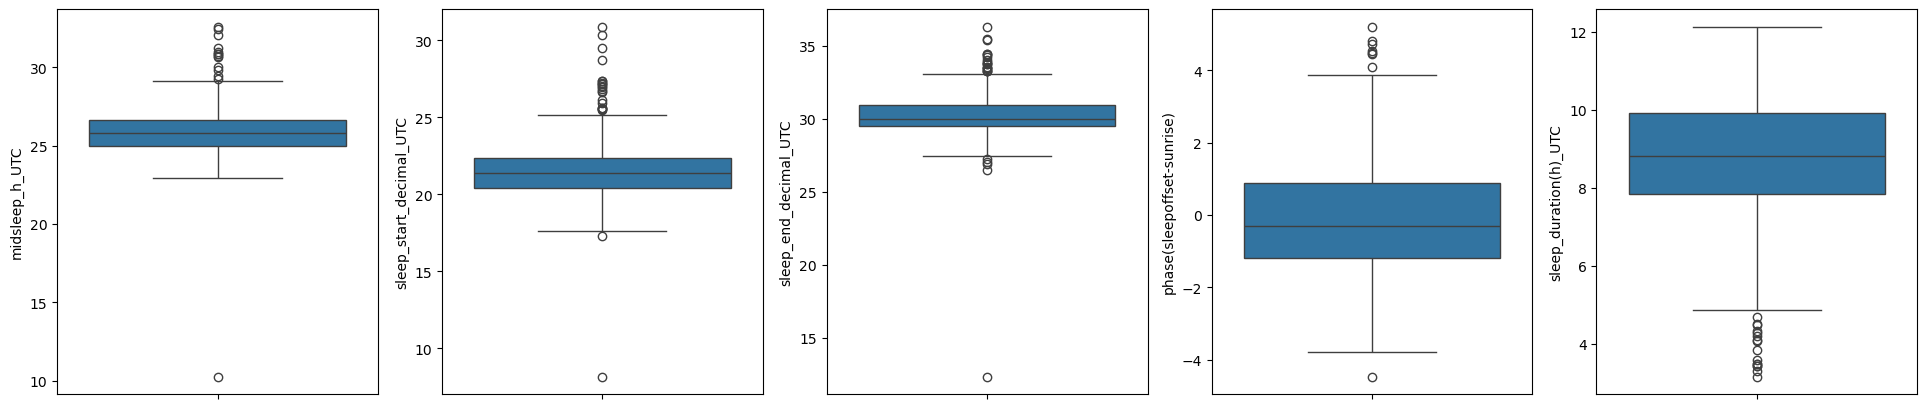

In [8]:
# box plot to verify the outliers in midpoint, sleep onset, sleep offset, phase, and sleep duration
fig, ax = plt.subplots(1, 5, figsize=(24, 5))
sns.boxplot(data=df['midsleep_h_UTC'], ax=ax[0])
sns.boxplot(data=df['sleep_start_decimal_UTC'], ax=ax[1])
sns.boxplot(data=df['sleep_end_decimal_UTC'], ax=ax[2])
sns.boxplot(data=df['phase(sleepoffset-sunrise)'], ax=ax[3])
sns.boxplot(data=df['sleep_duration(h)_UTC'], ax=ax[4])

plt.show()

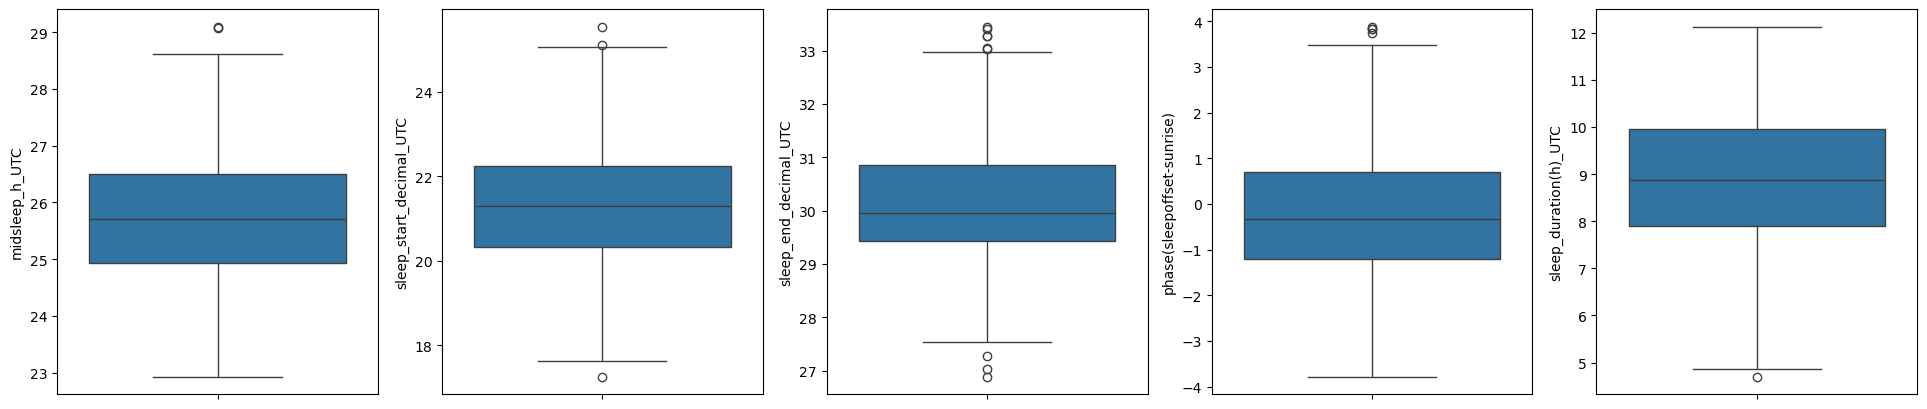

In [9]:
# remove outliers
# criteria: zscore of 3 means that the data point is 3 standard deviations away from the mean
# zscore of 3 is considered as an outlier
df = df[(np.abs(stats.zscore(df['midsleep_h_UTC'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_start_decimal_UTC'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_end_decimal_UTC'])) < 3)]
df = df[(np.abs(stats.zscore(df['phase(sleepoffset-sunrise)'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_duration(h)_UTC'])) < 3)]

# box plot to verify the outliers in midpoint, sleep onset, sleep offset, phase, and sleep duration
fig, ax = plt.subplots(1, 5, figsize=(24, 5))
sns.boxplot(data=df['midsleep_h_UTC'], ax=ax[0])
sns.boxplot(data=df['sleep_start_decimal_UTC'], ax=ax[1])
sns.boxplot(data=df['sleep_end_decimal_UTC'], ax=ax[2])
sns.boxplot(data=df['phase(sleepoffset-sunrise)'], ax=ax[3])
sns.boxplot(data=df['sleep_duration(h)_UTC'], ax=ax[4])

plt.show()

In [10]:
# define the start date
start_date = pd.to_datetime('2022-02-01')

In [11]:
# function to count the week of the year from the start date 2022-02-01
def calculate_week_of_year(start_datetime):
    return (start_datetime - start_date).days // 7 + 5

# apply the function to calculate the week of the year
df['week_of_year'] = df['date'].apply(calculate_week_of_year)

In [12]:
# adjust 'week of the year' to start from 0
df['week_of_year'] = df['week_of_year'] - 37

In [13]:
# rename the location column as 0=ITA, 1=UK
df['location'] = df['location'].map({0: 'ITA', 1: 'UK'})

# rename the weekday column as 0=work days, 1=free days
df['weekday_type'] = df['weekday_type'].map({0: 'work days', 1: 'free days'})

In [14]:
# calculate the sleep duration for work days and free days
df['sleep_duration(h)_UTC'] = df['sleep_duration(h)_UTC'].astype(float)
df['sleep_duration_work_days_UTC'] = df['sleep_duration(h)_UTC'] * (df['weekday_type'] == 'work days')
df['sleep_duration_free_days_UTC'] = df['sleep_duration(h)_UTC'] * (df['weekday_type'] == 'free days')

In [15]:
# filtered the midpoints by type of day of the week
# new dataframe with only the midpoints of the work days/free days
df_workdays = df[df['weekday_type'] == 'work days']
df_freedays = df[df['weekday_type'] == 'free days']

In [16]:
# create a new df for weekly jetlag analysis
data_jetlag_UTC = df 

In [17]:
# calculate the mean midpoint for each location, week and weekday
weekly_means_jetlag_UTC = data_jetlag_UTC.groupby(['location', 'week_of_year', 'weekday_type'])['midsleep_h_UTC'].mean().unstack()

In [18]:
# calculate the jet lag for week and weekday
weekly_means_jetlag_UTC['jet lag_UTC'] = weekly_means_jetlag_UTC['free days'] - weekly_means_jetlag_UTC['work days']

In [19]:
# add a column with the location to the weekly_means_jetlag_UTC
weekly_means_jetlag_UTC['location'] = weekly_means_jetlag_UTC.index.get_level_values(0)

In [20]:
# save the weekly_means_jetlag_UTC to an excel file
weekly_means_jetlag_UTC.to_excel(fpath + '\\weekly_means_jetlag_UTC.xlsx')

In [21]:
# rename columns
df = df.rename(columns={'sleep_duration(h)_UTC': 'sleep_duration_UTC'})
df = df.rename(columns={'phase(sleepoffset-sunrise)': 'phase'})

In [22]:
# Adding a 'season' column to the dataset based on the 'date' column
# Defining seasons based on months: 
# Winter (Dec-Feb), Spring (Mar-May), Summer (Jun-Aug), Autumn (Sep-Nov)
def assign_season(date):
    month = pd.to_datetime(date).month
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

In [23]:
# Applying the function to create a season column
df_workdays['season'] = df_workdays['date'].apply(assign_season)
df_freedays['season'] = df_freedays['date'].apply(assign_season)
df['season'] = df['date'].apply(assign_season)

C:\Users\gg00642\AppData\Local\Temp\ipykernel_18348\2974399819.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_workdays['season'] = df_workdays['date'].apply(assign_season)
C:\Users\gg00642\AppData\Local\Temp\ipykernel_18348\2974399819.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freedays['season'] = df_freedays['date'].apply(assign_season)


In [24]:
# create a new variable 'photoperiod' based on the location
# if column 'location' = 1 take the value from 'photoperiod (h, UK)' 
# if column 'location' = 0 then photoperiod (h, ITA)'
df['photoperiod'] = np.where(df['location'] == 'UK', df['photoperiod (h, UK)'], df['photoperiod (h, ITA)'])

In [25]:
# add a column with the photoperiod for the UK and ITA
df_workdays.loc[df_workdays['location'] == 'UK', 'photoperiod'] = df_workdays['photoperiod (h, UK)'] 
df_workdays.loc[df_workdays['location'] == 'ITA', 'photoperiod'] = df_workdays['photoperiod (h, ITA)']

C:\Users\gg00642\AppData\Local\Temp\ipykernel_18348\1608732957.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_workdays.loc[df_workdays['location'] == 'UK', 'photoperiod'] = df_workdays['photoperiod (h, UK)']


In [26]:
# add the photoperiod column to the df_freedays
df_freedays.loc[df_freedays['location'] == 'UK', 'photoperiod'] = df_freedays['photoperiod (h, UK)']
df_freedays.loc[df_freedays['location'] == 'ITA', 'photoperiod'] = df_freedays['photoperiod (h, ITA)']

C:\Users\gg00642\AppData\Local\Temp\ipykernel_18348\2381324628.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freedays.loc[df_freedays['location'] == 'UK', 'photoperiod'] = df_freedays['photoperiod (h, UK)']


In [27]:
# descpriptive statistics
all_descriptive = df.describe()
all_descriptive = all_descriptive.transpose()

In [28]:
# add the index as a column
all_descriptive['variable'] = all_descriptive.index 

#reset the index
all_descriptive = all_descriptive.reset_index(drop=True)

In [29]:
all_descriptive.to_excel(fpath + '\\all_descriptive.xlsx')

In [30]:
# descpriptive statistics for ITA
descriptive_ita = df[df['location'] == 'ITA'].describe()
descriptive_ita = descriptive_ita.transpose()

In [31]:
# remove the columns that are not needed
descriptive_ita = descriptive_ita.drop('sunrise (uk), hours')
descriptive_ita = descriptive_ita.drop('sunset (uk), hours')
descriptive_ita = descriptive_ita.drop('photoperiod (h, UK)')
descriptive_ita = descriptive_ita.drop('photoperiod (h, ITA)')
descriptive_ita = descriptive_ita.drop('DST(0=ST)')
descriptive_ita = descriptive_ita.drop('week_of_year')
descriptive_ita = descriptive_ita.drop('day_after_flight')
descriptive_ita = descriptive_ita.drop('start_datetime')
descriptive_ita = descriptive_ita.drop('end_datetime')
descriptive_ita = descriptive_ita.drop('date')
descriptive_ita = descriptive_ita.drop('midsleep_datetime')

In [32]:
descriptive_ita.to_excel(fpath + '\\descriptive_ita.xlsx')

In [33]:
# descpriptive statistics for UK
descriptive_uk = df[df['location'] == 'UK'].describe()
descriptive_uk = descriptive_uk.transpose()

In [34]:
# remove the columns that are not needed
descriptive_uk = descriptive_uk.drop('sunrise (uk), hours')
descriptive_uk = descriptive_uk.drop('sunset (uk), hours')
descriptive_uk = descriptive_uk.drop('photoperiod (h, UK)')
descriptive_uk = descriptive_uk.drop('photoperiod (h, ITA)')
descriptive_uk = descriptive_uk.drop('DST(0=ST)')
descriptive_uk = descriptive_uk.drop('week_of_year')
descriptive_uk = descriptive_uk.drop('day_after_flight')
descriptive_uk = descriptive_uk.drop('start_datetime')
descriptive_uk = descriptive_uk.drop('end_datetime')
descriptive_uk = descriptive_uk.drop('date')
descriptive_uk = descriptive_uk.drop('midsleep_datetime')

In [35]:
descriptive_uk.to_excel(fpath + '\\descriptive_uk.xlsx')

In [36]:
# % of time spent in each location
count_location = df['location'].value_counts(normalize=True) * 100

In [37]:
count_location

location
ITA    58.670989
UK     41.329011
Name: proportion, dtype: float64

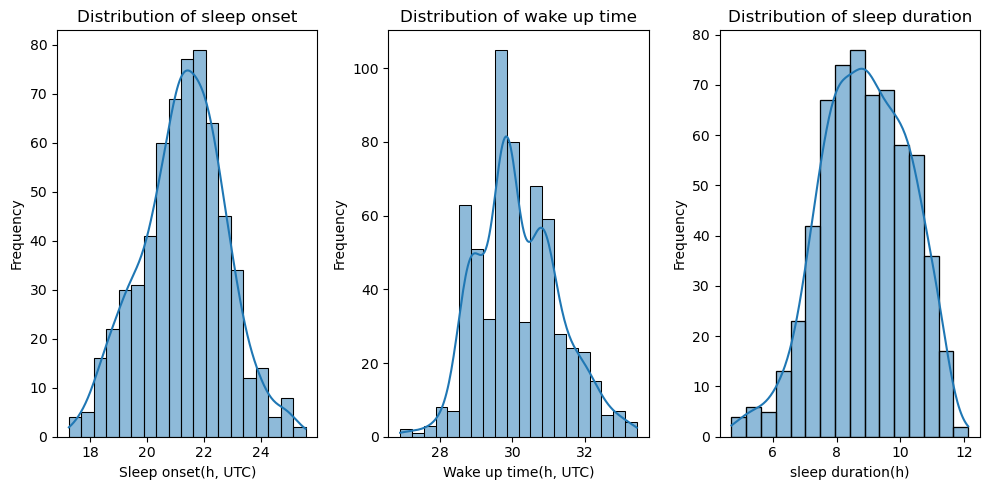

In [38]:
# distribution of the midpoint, sleep onset, sleep offset, and sleep duration
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['sleep_start_decimal_UTC'].dropna(), kde=True)
plt.title("Distribution of sleep onset")
plt.xlabel("Sleep onset(h, UTC)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
sns.histplot(df['sleep_end_decimal_UTC'].dropna(), kde=True)
plt.title("Distribution of wake up time")
plt.xlabel("Wake up time(h, UTC)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
sns.histplot(df['sleep_duration_UTC'].dropna(), kde=True)
plt.title("Distribution of sleep duration")
plt.xlabel("sleep duration(h)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

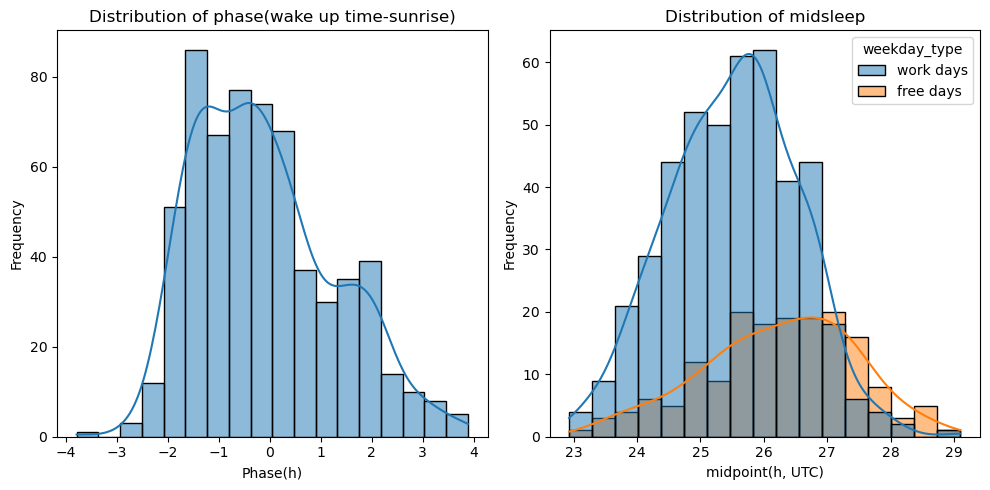

In [39]:
# distribution of phase and midpoint of sleep
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['phase'].dropna(), kde=True)
plt.title("Distribution of phase(wake up time-sunrise)")
plt.xlabel("Phase(h)")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='midsleep_h_UTC', hue='weekday_type', kde=True)
plt.title("Distribution of midsleep")
plt.xlabel("midpoint(h, UTC)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [40]:
# test normality of the data using Shapiro-Wilk test 
# Null hipotesis(H0): data is normally distributed
shapiro_test_sleep_duration = stats.shapiro(df['sleep_duration_UTC'])
shapiro_test_midsleep = stats.shapiro(df['midsleep_h_UTC'])
shapiro_test_sleep_start = stats.shapiro(df['sleep_start_decimal_UTC'])
shapiro_test_sleep_end = stats.shapiro(df['sleep_end_decimal_UTC'])
shapiro_test_phase = stats.shapiro(df['phase'])

In [41]:
shapiro_results_x = pd.DataFrame({
    'Variable': ['sleep_duration(h)', 'midsleep_h_UTC', 'sleep_start_decimal_UTC', 'sleep_end_decimal_UTC', 'phase(sleepoffset-sunrise)'],
    'Shapiro-Wilk test': [shapiro_test_sleep_duration, shapiro_test_midsleep, shapiro_test_sleep_start, shapiro_test_sleep_end, shapiro_test_phase]
})

In [42]:
shapiro_results_x

,Variable,Shapiro-Wilk test
0,sleep_duration(h),"(0.9891354861507841, 0.00015585670064701592)"
1,midsleep_h_UTC,"(0.9971768363510296, 0.3686335151645132)"
2,sleep_start_decimal_UTC,"(0.9950464513734262, 0.04459411275419412)"
3,sleep_end_decimal_UTC,"(0.9834449855930151, 1.852098496753992e-06)"
4,phase(sleepoffset-sunrise),"(0.9658625464242095, 8.665136781002509e-11)"


In [43]:
# test normality of the data using Shapiro-Wilk test for work days and free days (midpoint of sleep)
shapiro_test_midpoint_free = stats.shapiro(df[df['weekday_type'] == 'free days']['midsleep_h_UTC'])
shapiro_test_midpoint_work = stats.shapiro(df[df['weekday_type'] == 'work days']['midsleep_h_UTC'])

In [44]:
shapiro_results_free_work = pd.DataFrame({
    'Weekday type': ['free days', 'work days'],
    'Shapiro-Wilk test': [shapiro_test_midpoint_free, shapiro_test_midpoint_work]
})

In [45]:
shapiro_results_free_work

,Weekday type,Shapiro-Wilk test
0,free days,"(0.9879358516474632, 0.15683098256109368)"
1,work days,"(0.9962480307557194, 0.37427892428554643)"


In [46]:
# descriptive statistics by location
df_grouped_location = df.groupby('location').describe()
df_grouped_location = df_grouped_location.transpose()

In [47]:
# compare the variables between ITA and UK
ttest_midsleep_all_loc = stats.ttest_ind(df[df['location'] == 'ITA']['midsleep_h_UTC'], df[df['location'] == 'UK']['midsleep_h_UTC'])
ttest_midsleep_workdays_loc = stats.ttest_ind(df_workdays[df_workdays['location'] == 'ITA']['midsleep_h_UTC'], df_workdays[df_workdays['location'] == 'UK']['midsleep_h_UTC'])
ttest_midsleep_freedays_loc = stats.ttest_ind(df_freedays[df_freedays['location'] == 'ITA']['midsleep_h_UTC'], df_freedays[df_freedays['location'] == 'UK']['midsleep_h_UTC'])
utest_duration_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_duration_UTC'], df[df['location'] == 'UK']['sleep_duration_UTC'])
utest_phase_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['phase'], df[df['location'] == 'UK']['phase'])
utest_start_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_start_decimal_UTC'], df[df['location'] == 'UK']['sleep_start_decimal_UTC'])
utest_end_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_end_decimal_UTC'], df[df['location'] == 'UK']['sleep_end_decimal_UTC'])

In [48]:
# print the results
print('T test results by location')
print('Midsleep_all:', ttest_midsleep_all_loc)
print('Midsleep_work:', ttest_midsleep_workdays_loc)
print('Midsleep_free:', ttest_midsleep_freedays_loc)
print('U test results by location')
print('Sleep_onset:', utest_start_loc)
print('Sleep_offset:', utest_end_loc)
print('Sleep_duration:', utest_duration_loc)
print('Phase:', utest_phase_loc)

T test results by location
Midsleep_all: TtestResult(statistic=-8.159460252852266, pvalue=1.9030279294297676e-15, df=615.0)
Midsleep_work: TtestResult(statistic=-7.739324282826716, pvalue=6.748588907056264e-14, df=446.0)
Midsleep_free: TtestResult(statistic=-4.222621190527396, pvalue=3.958495061643102e-05, df=167.0)
U test results by location
Sleep_onset: MannwhitneyuResult(statistic=33745.5, pvalue=1.2607952357982124e-08)
Sleep_offset: MannwhitneyuResult(statistic=28285.5, pvalue=2.4950327204628183e-16)
Sleep_duration: MannwhitneyuResult(statistic=45676.0, pvalue=0.8262919376637582)
Phase: MannwhitneyuResult(statistic=28800.0, pvalue=1.7277522930762417e-15)


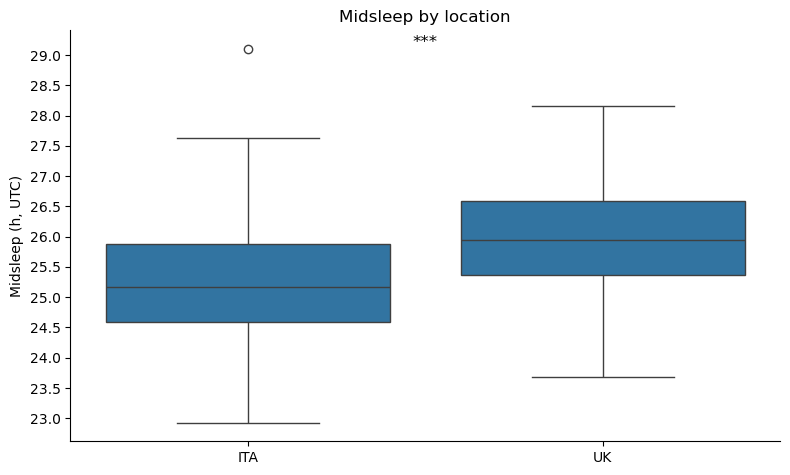

In [49]:
# plot the midpoint of sleep by location
plt.figure(figsize=(8, 5))
sns.boxplot(x='location', y='midsleep_h_UTC', data=df_workdays)
plt.title('Midsleep by location')
plt.suptitle('')  
plt.xlabel('')
plt.ylabel('Midsleep (h, UTC)')

plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)

plt.gca().yaxis.set_major_locator(MultipleLocator(0.5)) # gcd stands for 'get current axis'
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.tight_layout()

plt.show()

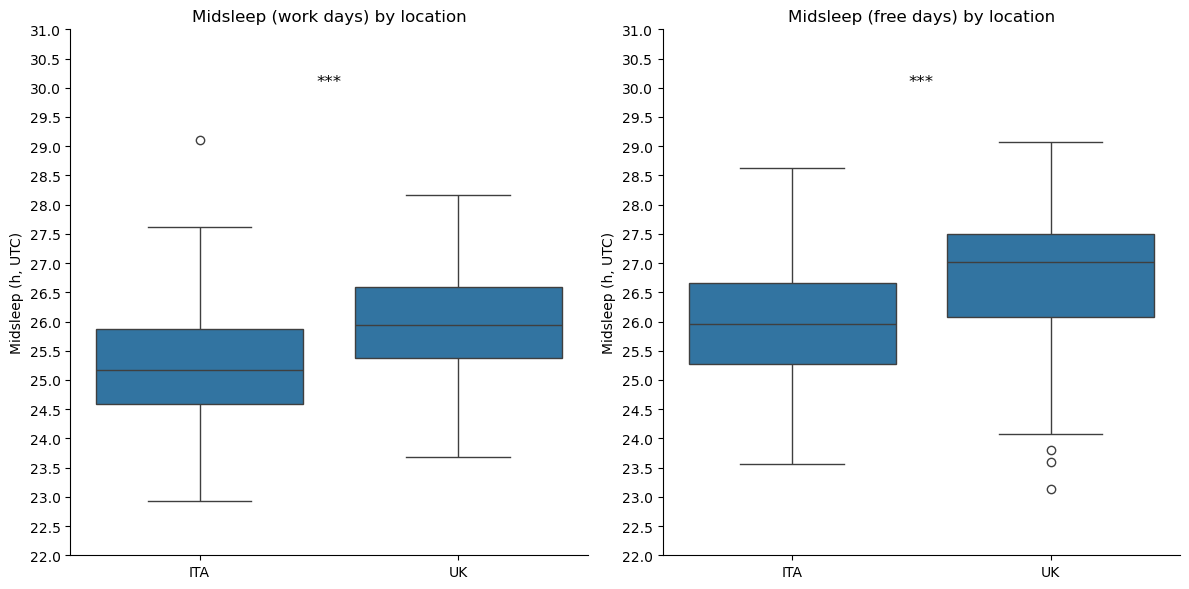

In [50]:
# plot the midpoint of sleep by location for free days and work days
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(x='location', y='midsleep_h_UTC', data=df_workdays, ax=ax[0])
ax[0].set_title('Midsleep (work days) by location')
ax[0].set_ylabel('Midsleep (h, UTC)')
ax[0].set_xlabel('')
ax[0].yaxis.set_major_locator(MultipleLocator(0.5))
ax[0].set_ylim(22, 31)
ax[0].annotate('***', xy=(0.5, 0.9), xycoords='axes fraction', ha='center', va='center', fontsize=12) #add a significance line of ** for the p-value < 0.001

sns.boxplot(x='location', y='midsleep_h_UTC', data=df_freedays, ax=ax[1])
ax[1].set_title('Midsleep (free days) by location')
ax[1].set_ylabel('Midsleep (h, UTC)')
ax[1].set_xlabel('')
ax[1].yaxis.set_major_locator(MultipleLocator(0.5))
ax[1].set_ylim(ax[0].get_ylim())
ax[1].annotate('***', xy=(0.5, 0.9), xycoords='axes fraction', ha='center', va='center', fontsize=12) #add a significance line of  for the p-value < 0.001
    
sns.despine()
plt.grid(False)
plt.gca().spines['bottom'].set_color('black') # set the color of the x-axis to black
plt.gca().spines['left'].set_color('black')
plt.tight_layout()
plt.show()

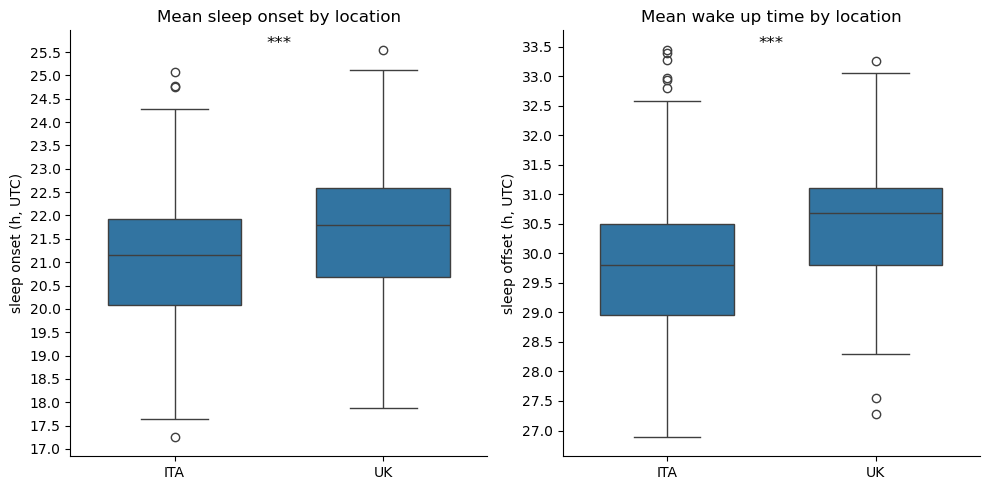

In [51]:
# plot the sleep onset and sleep offset by location
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='location', y='sleep_start_decimal_UTC', data=df, gap=0.2)
plt.title('Mean sleep onset by location')
plt.xlabel('')
plt.ylabel('sleep onset (h, UTC)')
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12) #add a significance line to the subplot
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

plt.subplot(1, 2, 2)
sns.boxplot(x='location', y='sleep_end_decimal_UTC', data=df, gap=0.2)
plt.title('Mean wake up time by location')
plt.xlabel('')
plt.ylabel('sleep offset (h, UTC)')
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12) #add a significance line to the subplot
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

sns.despine()
plt.tight_layout()
plt.show()

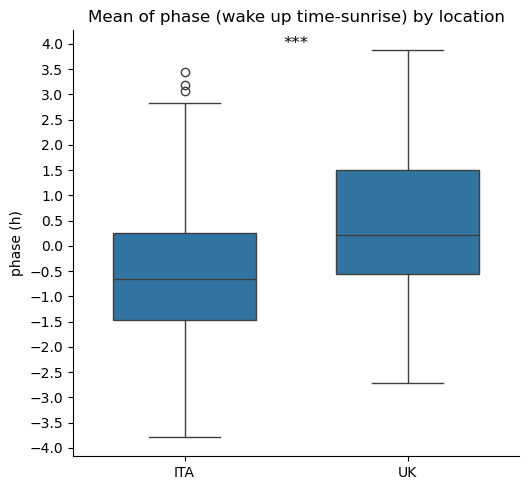

In [52]:
# plot the phase (sleep offset-sunrise) by location 
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='location', y='phase', data=df, gap=0.2)
plt.title('Mean of phase (wake up time-sunrise) by location')
plt.xlabel('')
plt.ylabel('phase (h)')
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

sns.despine()
plt.tight_layout()
plt.show()

_Weekly Jetlag_

In [53]:
# drop the rows with missing values
jetlag_clean = weekly_means_jetlag_UTC['jet lag_UTC'].dropna()

In [54]:
# Test normality of the jet lag data using Shapiro-Wilk test 
# H0: data is normally distributed
shapiro_test_jetlag = stats.shapiro(jetlag_clean)

In [55]:
print('Shapiro test result for jet lag:')
print(shapiro_test_jetlag)

Shapiro test result for jet lag:
ShapiroResult(statistic=0.9700797152032106, pvalue=0.02241756551347584)


In [56]:
# test the difference in jet lag between the two locations
utest_jetlag = stats.mannwhitneyu(weekly_means_jetlag_UTC[weekly_means_jetlag_UTC['location'] == 'ITA']['jet lag_UTC'].dropna(), weekly_means_jetlag_UTC[weekly_means_jetlag_UTC['location'] == 'UK']['jet lag_UTC'].dropna())

In [57]:
print('U test result for jet lag by location:')
print(utest_jetlag)

U test result for jet lag by location:
MannwhitneyuResult(statistic=1246.5, pvalue=0.8449649335819522)


_Season and sleep-wake pattern_

In [58]:
# remove NaN values from the columns and create a new dataframe
df1 = df.dropna(subset=['sleep_duration_UTC']) 
df1 = df.dropna(subset=['phase'])

In [59]:
ols_midsleep_season = ols('midsleep_h_UTC ~ C(season)', data=df1).fit() # generate and fit the regression model
anova_midsleep_result_season = sm.stats.anova_lm(ols_midsleep_season, typ=3) # fit the ANOVA model and get the results

In [60]:
print('ANOVA Result:')
print(anova_midsleep_result_season)

ANOVA Result:
                  sum_sq     df              F        PR(>F)
Intercept  137505.588759    1.0  127761.197870  0.000000e+00
C(season)      96.971893    3.0      30.033313  3.987389e-18
Residual      659.753723  613.0            NaN           NaN


In [61]:
# Post hoc test: perform a Tukey HSD test to compare the means
tukey_results_season1 = pairwise_tukeyhsd(df1['midsleep_h_UTC'], df1['season'])
print(tukey_results_season1)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
Autumn Spring  -0.1704  0.493 -0.4816  0.1408  False
Autumn Summer  -0.4392 0.0014 -0.7461 -0.1322   True
Autumn Winter   0.6482    0.0  0.3744  0.9221   True
Spring Summer  -0.2687 0.1979  -0.619  0.0815  False
Spring Winter   0.8186    0.0   0.497  1.1403   True
Summer Winter   1.0874    0.0  0.7699  1.4049   True
----------------------------------------------------


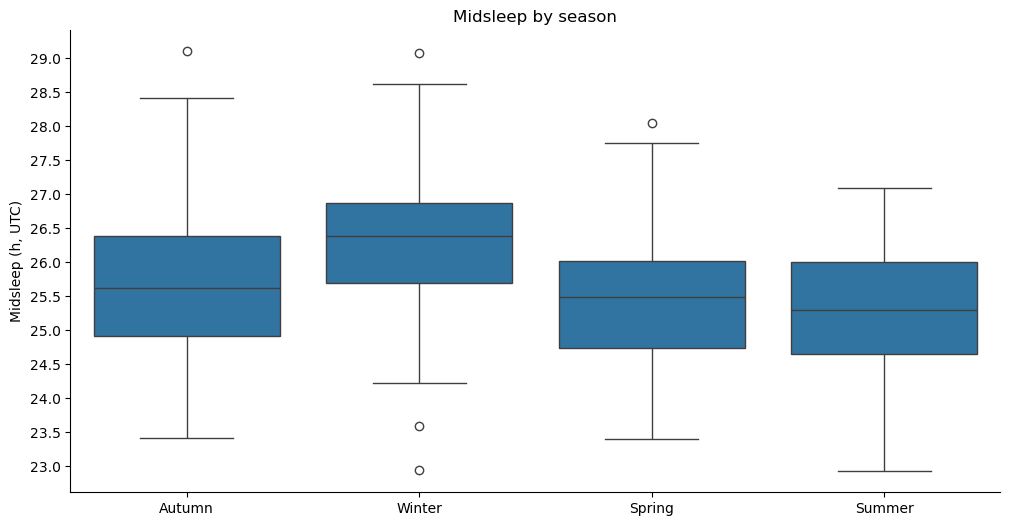

In [62]:
# sleep midpoint by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='midsleep_h_UTC', data=df1)
plt.title('Midsleep by season')
plt.suptitle('')  # add space between the title and the plot
plt.ylabel('Midsleep (h, UTC)')
plt.xlabel('')
sns.despine()
plt.grid(False)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.gca().spines['bottom'].set_color('black') 
plt.gca().spines['left'].set_color('black')
plt.show()

In [63]:
# Kruskal-Wallis test : compare the sleep duration, phase, sleep onset, and sleep offset between the seasons
kw_sleep_duration_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_duration_UTC'], df[df['season'] == 'Spring']['sleep_duration_UTC'], df[df['season'] == 'Summer']['sleep_duration_UTC'], df[df['season'] == 'Autumn']['sleep_duration_UTC'])
kw_phase_season = stats.kruskal(df[df['season'] == 'Winter']['phase'], df[df['season'] == 'Spring']['phase'], df[df['season'] == 'Summer']['phase'], df[df['season'] == 'Autumn']['phase'])
kw_start_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_start_decimal_UTC'], df[df['season'] == 'Spring']['sleep_start_decimal_UTC'], df[df['season'] == 'Summer']['sleep_start_decimal_UTC'], df[df['season'] == 'Autumn']['sleep_start_decimal_UTC'])
kw_end_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_end_decimal_UTC'], df[df['season'] == 'Spring']['sleep_end_decimal_UTC'], df[df['season'] == 'Summer']['sleep_end_decimal_UTC'], df[df['season'] == 'Autumn']['sleep_end_decimal_UTC'])

In [64]:
print('Results for Kruskal-Wallis test for the sleep duration by season')
print(kw_sleep_duration_season)
print('Results for Kruskal-Wallis test for the phase by season')
print(kw_phase_season)
print('Results for Kruskal-Wallis test for the sleep onset by season')
print(kw_start_season)
print('Results for Kruskal-Wallis test for the sleep offset by season')
print(kw_end_season)

Results for Kruskal-Wallis test for the sleep duration by season
KruskalResult(statistic=6.299456425848161, pvalue=0.0979159798324883)
Results for Kruskal-Wallis test for the phase by season
KruskalResult(statistic=214.12242339597466, pvalue=3.742759337078632e-46)
Results for Kruskal-Wallis test for the sleep onset by season
KruskalResult(statistic=46.005394829269385, pvalue=5.656526334267493e-10)
Results for Kruskal-Wallis test for the sleep offset by season
KruskalResult(statistic=88.66044261567438, pvalue=4.2486662093527966e-19)


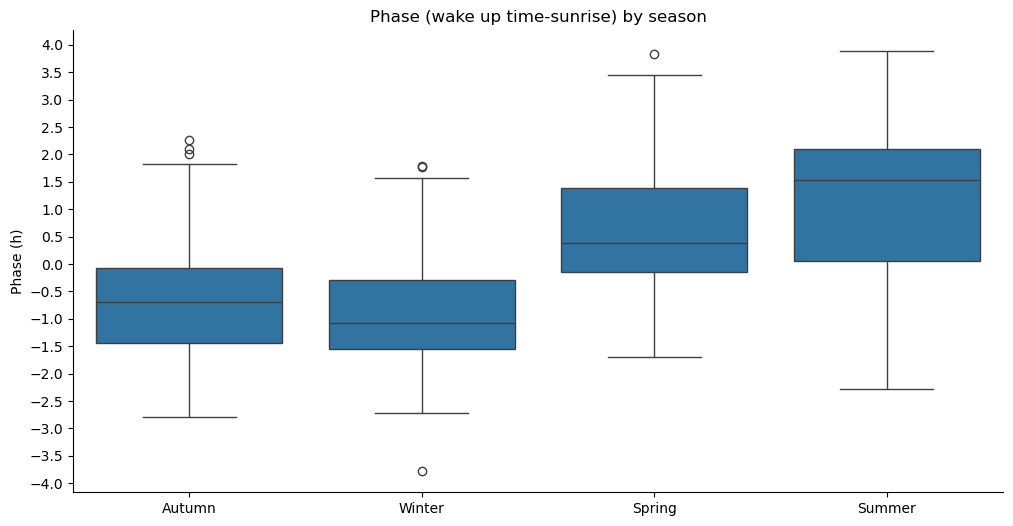

In [65]:
# phase (sleep offset - sunrise) by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='phase', data=df)
plt.title('Phase (wake up time-sunrise) by season')
plt.suptitle('')  # add space after the title
plt.ylabel('Phase (h)')
plt.xlabel('')
sns.despine()
plt.grid(False)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

In [66]:
# Post hoc test: perform a Tukey HSD test to compare the means
tukey_results_season2 = pairwise_tukeyhsd(df1['phase'], df1['season'])
print(tukey_results_season2)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
Autumn Spring   1.2883    0.0  0.9602  1.6164   True
Autumn Summer   1.7409    0.0  1.4173  2.0645   True
Autumn Winter  -0.2578 0.0991 -0.5466  0.0309  False
Spring Summer   0.4526  0.009  0.0833  0.8219   True
Spring Winter  -1.5461    0.0 -1.8853 -1.2069   True
Summer Winter  -1.9987    0.0 -2.3336 -1.6639   True
----------------------------------------------------


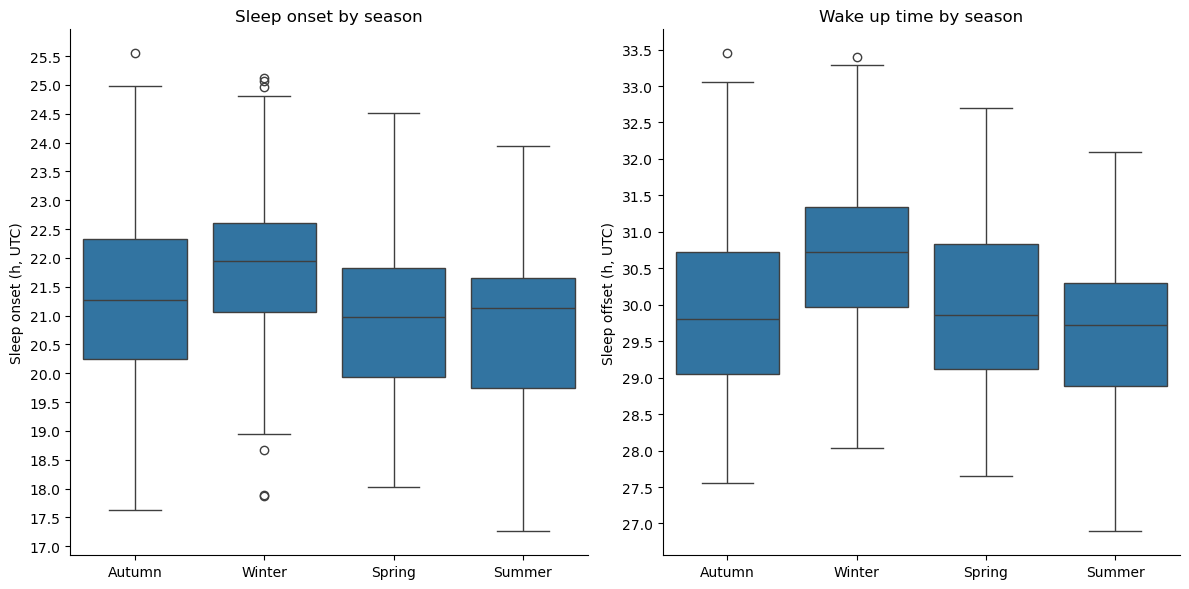

In [67]:
# sleep onset and offset by season
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='season', y='sleep_start_decimal_UTC', data=df)
plt.title('Sleep onset by season')
plt.ylabel('Sleep onset (h, UTC)')
plt.xlabel('')
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

plt.subplot(1, 2, 2)
sns.boxplot(x='season', y='sleep_end_decimal_UTC', data=df)
plt.title('Wake up time by season')
plt.ylabel('Sleep offset (h, UTC)')
plt.xlabel('')
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.tight_layout()

plt.show()

_DST and sleep-wake pattern_

In [68]:
# rename the column
df = df.rename(columns={'DST(0=ST)': 'DST_0'})

In [69]:
# remove the rows with missing values in the columns
df2 = df.dropna(subset=['sleep_duration_UTC'])
df2 = df.dropna(subset=['phase'])

In [70]:
# t-test to compare the midpoint of sleep between DST and non-DST
ttest_midsleep_dst = stats.ttest_ind(df2[df2['DST_0'] == 0]['midsleep_h_UTC'], df2[df2['DST_0'] == 1]['midsleep_h_UTC'])

In [71]:
print('T test result for the sleep midpoint by DST:')
print(ttest_midsleep_dst)

T test result for the sleep midpoint by DST:
TtestResult(statistic=12.354597385897629, pvalue=1.7746117198568022e-31, df=615.0)


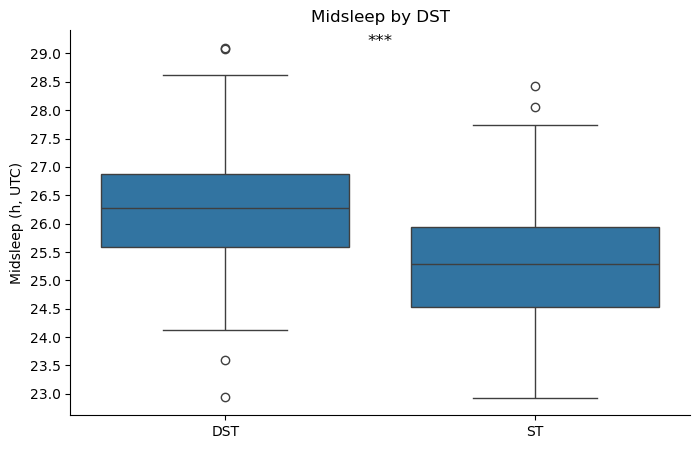

In [72]:
# sleep midpoint by DST
plt.figure(figsize=(8, 5))
sns.boxplot(x='DST_0', y='midsleep_h_UTC', data=df2)
plt.title('Midsleep by DST')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Midsleep (h, UTC)')
plt.xlabel('')
plt.xticks([0, 1], ['DST', 'ST'])
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
sns.despine()
plt.grid(False)

plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

In [73]:
# Mann Whitney U test : compare the sleep duration, phase, sleep onset, and sleep offset between DST and non-DST
utest_sleep_duration_dst = stats.mannwhitneyu(df2[df2['DST_0'] == 0]['sleep_duration_UTC'], df2[df2['DST_0'] == 1]['sleep_duration_UTC'])
utest_phase_dst = stats.mannwhitneyu(df2[df2['DST_0'] == 0]['phase'], df2[df2['DST_0'] == 1]['phase'])
utest_start_dst = stats.mannwhitneyu(df2[df2['DST_0'] == 0]['sleep_start_decimal_UTC'], df2[df2['DST_0'] == 1]['sleep_start_decimal_UTC'])
utest_end_dst = stats.mannwhitneyu(df2[df2['DST_0'] == 0]['sleep_end_decimal_UTC'], df2[df2['DST_0'] == 1]['sleep_end_decimal_UTC'])

In [74]:
print('Results for Mann-Whitney U test for the sleep duration by dst')
print(utest_sleep_duration_dst)
print('Results for Mann-Whitney U test for the phase by dst')
print(utest_phase_dst)
print('Results for Mann-Whitney U test for the sleep onset by dst')
print(utest_start_dst)
print('Results for Mann-Whitney U test for the sleep offset by dst')
print(utest_end_dst)

Results for Mann-Whitney U test for the sleep duration by dst
MannwhitneyuResult(statistic=50064.5, pvalue=0.2306490490508717)
Results for Mann-Whitney U test for the phase by dst
MannwhitneyuResult(statistic=27679.5, pvalue=4.2527182877577545e-19)
Results for Mann-Whitney U test for the sleep onset by dst
MannwhitneyuResult(statistic=64866.5, pvalue=2.8636426871434215e-15)
Results for Mann-Whitney U test for the sleep offset by dst
MannwhitneyuResult(statistic=74528.5, pvalue=1.3305138200322353e-34)


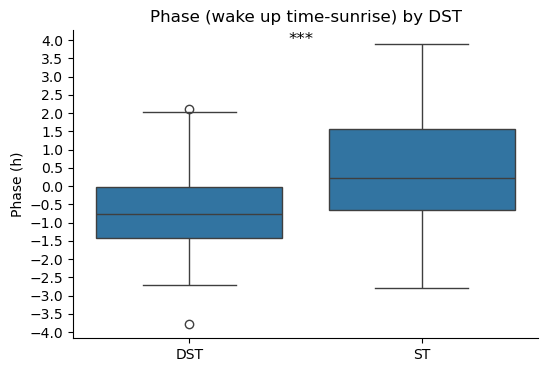

In [75]:
# phase (sleep offset - sunrise) by DST
plt.figure(figsize=(6, 4))
sns.boxplot(x='DST_0', y='phase', data=df2)
plt.title('Phase (wake up time-sunrise) by DST')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Phase (h)')
plt.xlabel('')
plt.xticks([0, 1], ['DST', 'ST'])
sns.despine()
plt.grid(False)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.annotate('***', xy=(0.49, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

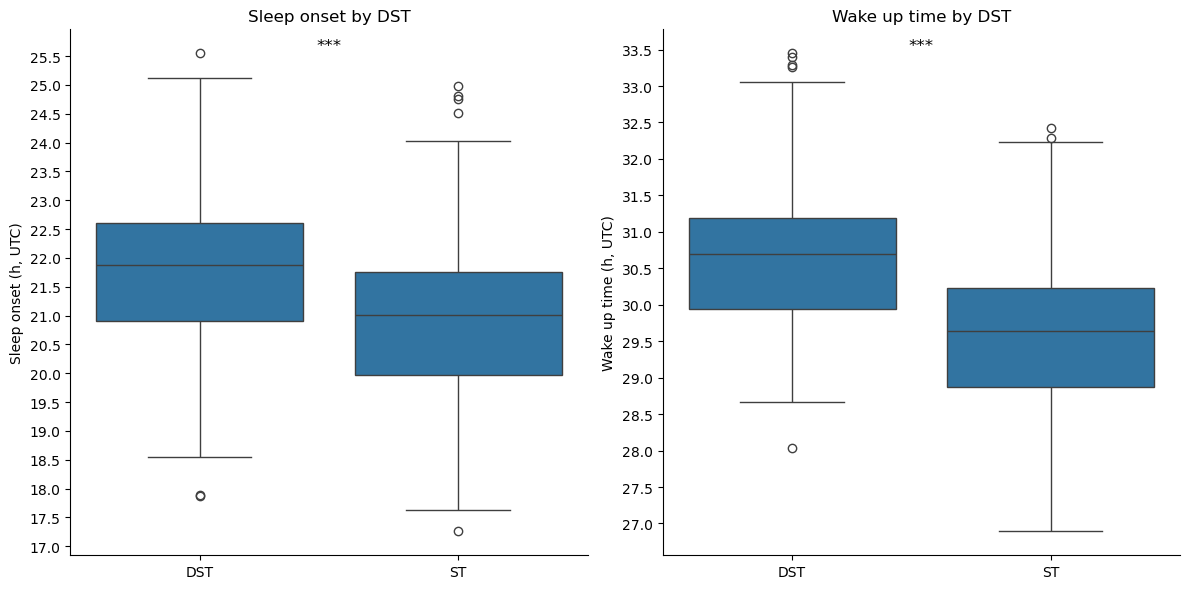

In [76]:
# sleep onset and offset by DST
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='DST_0', y='sleep_start_decimal_UTC', data=df2)
plt.title('Sleep onset by DST')
plt.ylabel('Sleep onset (h, UTC)')
plt.xlabel('')
plt.xticks([0, 1], ['DST', 'ST'])
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

plt.subplot(1, 2, 2)
sns.boxplot(x='DST_0', y='sleep_end_decimal_UTC', data=df2)
plt.title('Wake up time by DST')
plt.ylabel('Wake up time (h, UTC)')
plt.xlabel('')
plt.xticks([0, 1], ['DST', 'ST'])
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.tight_layout()

plt.show()

_Photoperiod and sleep-wake pattern_

In [77]:
# correlation between sleep-wake variables and photoperiod
correlation_test1 = stats.pearsonr(df['midsleep_h_UTC'], df['photoperiod'])
correlation_test2 = stats.pearsonr(df_workdays['midsleep_h_UTC'], df_workdays['photoperiod'])
correlation_test3 = stats.pearsonr(df_freedays['midsleep_h_UTC'], df_freedays['photoperiod'])
correlation_test4 = stats.spearmanr(df['sleep_duration_UTC'], df['photoperiod'])
correlation_test5 = stats.spearmanr(df['sleep_end_decimal_UTC'], df['photoperiod'])

In [78]:
# extract the coefficients and p-values from the correlation test results
correlation_coeff = [correlation_test1.statistic, correlation_test2.statistic, correlation_test3.statistic, correlation_test4.statistic, correlation_test5.correlation]
p_values = [correlation_test1.pvalue, correlation_test2.pvalue, correlation_test3.pvalue, correlation_test4.pvalue, correlation_test5.pvalue]

In [79]:
# create a DataFrame with the results
correlation_results = pd.DataFrame({
    'Variables': ['midsleep UTC vs photoperiod', 'midsleep (work) UTC vs photoperiod', 'midsleep (free) UTC vs photoperiod', 'sleep duration UTC vs photoperiod', 'sleep offset UTC vs photoperiod'],
    'Coefficient': correlation_coeff,
    'P-value': p_values
})

correlation_results

,Variables,Coefficient,P-value
0,midsleep UTC vs photoperiod,-0.376934,2.896843e-22
1,midsleep (work) UTC vs photoperiod,-0.389630,1.083786e-17
2,midsleep (free) UTC vs photoperiod,-0.406348,4.212530e-08
3,sleep duration UTC vs photoperiod,0.013112,7.451490e-01
4,sleep offset UTC vs photoperiod,-0.386210,2.213727e-23


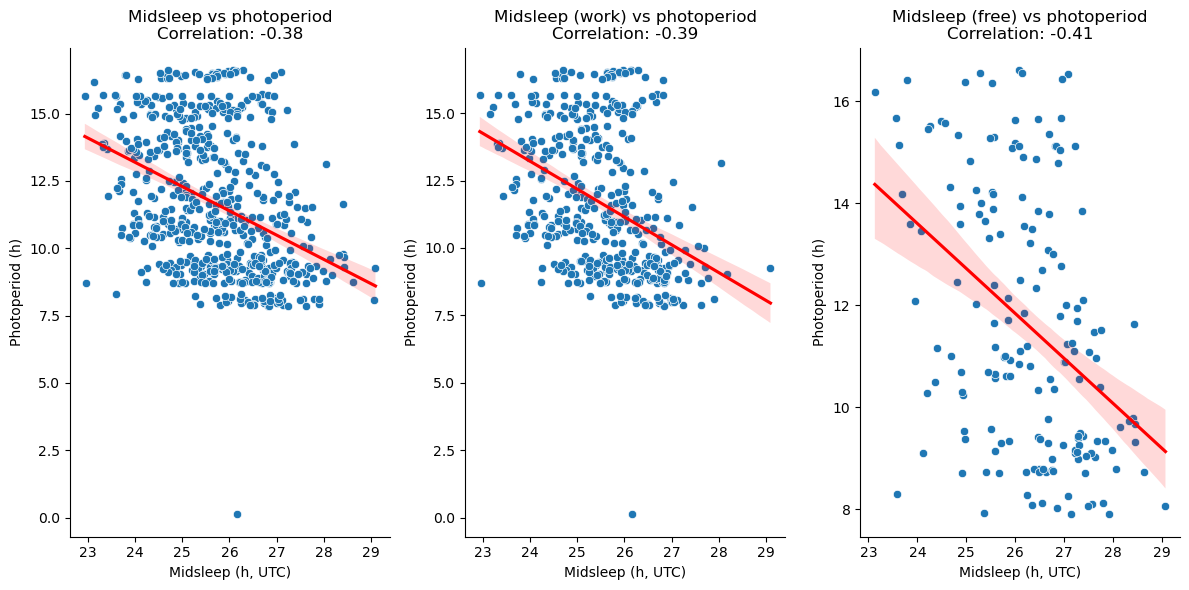

In [80]:
from scipy import stats

# plot the correlation between the midpoint of sleep and photoperiod, for all the data, work days and free days
plt.figure(figsize=(12, 6))

# All data
plt.subplot(1, 3, 1)
sns.scatterplot(x='midsleep_h_UTC', y='photoperiod', data=df)
sns.regplot(x='midsleep_h_UTC', y='photoperiod', data=df, scatter=False, color='red')
corr_all, _ = stats.pearsonr(df['midsleep_h_UTC'], df['photoperiod'])
plt.title(f'Midsleep vs photoperiod\nCorrelation: {corr_all:.2f}')
plt.xlabel('Midsleep (h, UTC)')
plt.ylabel('Photoperiod (h)')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)

# Work days
plt.subplot(1, 3, 2)
sns.scatterplot(x='midsleep_h_UTC', y='photoperiod', data=df_workdays)
sns.regplot(x='midsleep_h_UTC', y='photoperiod', data=df_workdays, scatter=False, color='red')
corr_work, _ = stats.pearsonr(df_workdays['midsleep_h_UTC'], df_workdays['photoperiod'])
plt.title(f'Midsleep (work) vs photoperiod\nCorrelation: {corr_work:.2f}')
plt.xlabel('Midsleep (h, UTC)')
plt.ylabel('Photoperiod (h)')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)

# Free days
plt.subplot(1, 3, 3)
sns.scatterplot(x='midsleep_h_UTC', y='photoperiod', data=df_freedays)
sns.regplot(x='midsleep_h_UTC', y='photoperiod', data=df_freedays, scatter=False, color='red')
corr_free, _ = stats.pearsonr(df_freedays['midsleep_h_UTC'], df_freedays['photoperiod'])
plt.title(f'Midsleep (free) vs photoperiod\nCorrelation: {corr_free:.2f}')
plt.xlabel('Midsleep (h, UTC)')
plt.ylabel('Photoperiod (h)')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)

plt.tight_layout()
plt.show()

_Weekly IV, IS and RA_

In [81]:
# load the datasets required for the analysis
weekly_values = pd.read_csv(fpath + '\\2.0_weekly_IV_IS_RA_values_with_dates.csv')
weekly_jetlag = weekly_means_jetlag_UTC

In [82]:
# split Date_Range into Start_Date and End_Date in weekly_values
weekly_values[['Start_Date', 'End_Date']] = weekly_values['Date_Range'].str.split(' to ', expand=True)

In [83]:
# convert Start_Date and End_Date to datetime format
weekly_values['Start_Date'] = pd.to_datetime(weekly_values['Start_Date'])
weekly_values['End_Date'] = pd.to_datetime(weekly_values['End_Date'])

In [84]:
# merge by matching the week number extracted from Start_Date with week_of_year in weekly_jetlag
merged_data = pd.merge(
    weekly_values,
    weekly_jetlag,
    left_on=weekly_values['Start_Date'].dt.isocalendar().week,
    right_on='week_of_year',
    how='inner'
)

In [ ]:
merged_data.head()

,week_of_year,Date_Range,IS,IV,RA,Start_Date,End_Date,free days,work days,jet lag_UTC,location
0,15,2023-04-12 to 2023-04-18,NaN,0.024172,NaN,2023-04-12,2023-04-18,26.437500,25.821875,0.615625,ITA
1,32,2023-08-09 to 2023-08-15,NaN,0.048807,NaN,2023-08-09,2023-08-15,24.600000,25.093333,-0.493333,ITA
2,31,2024-07-31 to 2024-08-06,NaN,0.027033,0.949047,2024-07-31,2024-08-06,26.460417,24.690625,1.769792,ITA
3,33,2023-08-16 to 2023-08-22,NaN,0.053677,0.948446,2023-08-16,2023-08-22,26.397917,25.026667,1.371250,UK
4,9,2023-03-01 to 2023-03-07,NaN,0.040270,0.953698,2023-03-01,2023-03-07,26.406250,25.628333,0.777917,ITA


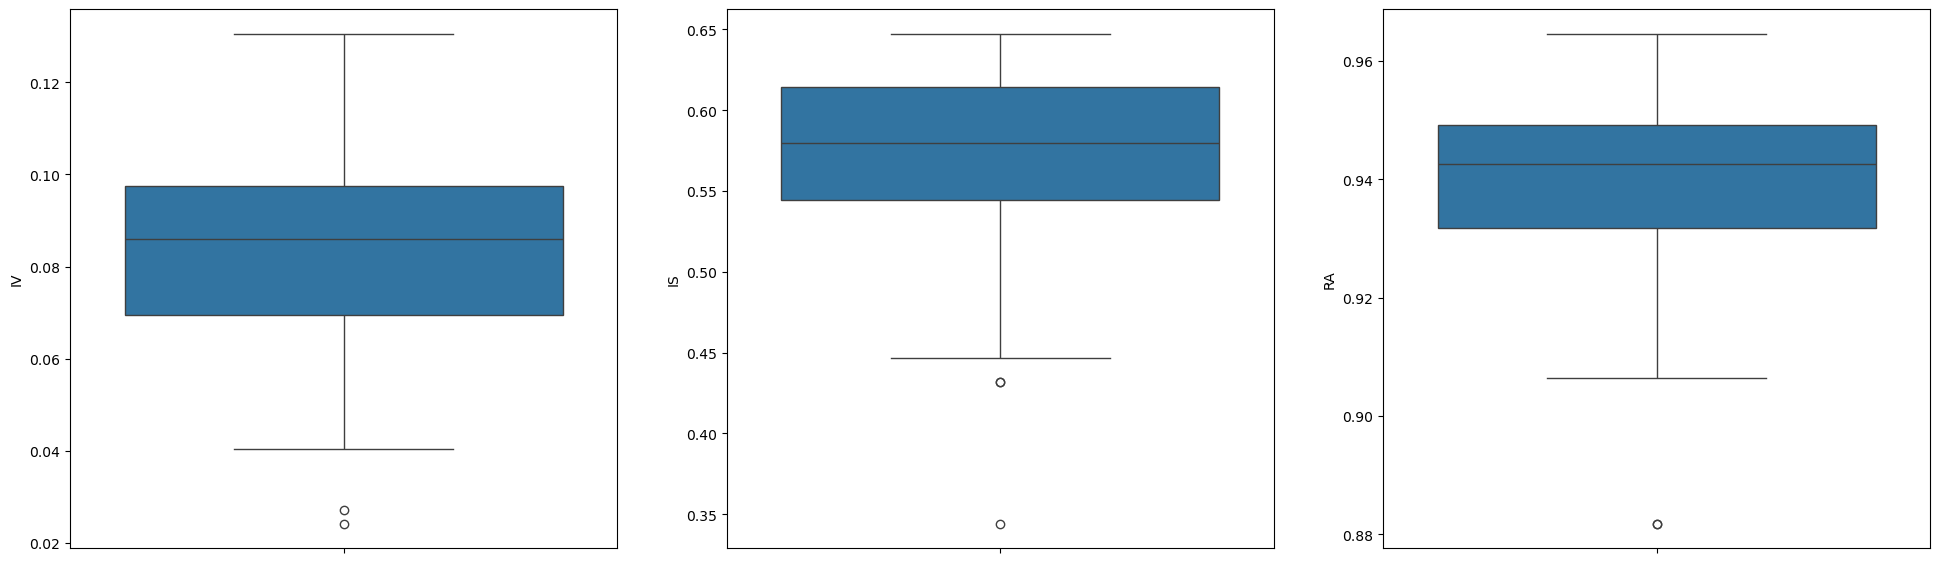

In [86]:
# box plot to verify the outliers in IV, IS, and RA
fig, ax = plt.subplots(1, 3, figsize=(24, 7))
sns.boxplot(data=merged_data['IV'], ax=ax[0])
sns.boxplot(data=merged_data['IS'], ax=ax[1])
sns.boxplot(data=merged_data['RA'], ax=ax[2])
plt.show()

In [87]:
# summary statistics
summary_stats = merged_data.groupby("location")[['IV', 'IS', 'RA']].describe()
summary_stats

IV                                                              \
         count      mean       std       min       25%       50%       75%   
location                                                                     
ITA       53.0  0.080466  0.022129  0.024172  0.067942  0.082638  0.093785   
UK        36.0  0.088307  0.017596  0.053677  0.075609  0.087177  0.098561   

                      IS            ...                        RA            \
               max count      mean  ...       75%       max count      mean   
location                            ...                                       
ITA       0.130562  48.0  0.574327  ...  0.614767  0.647358  50.0  0.940170   
UK        0.130562  34.0  0.567904  ...  0.613489  0.645810  34.0  0.937674   

                                                                     
              std       min       25%       50%       75%       max  
location                                                             
ITA       0.01533  0.881815  0.931972  0.942574  0.950680  0.964584  
UK        0.01699  0.881815  0.930985  0.942574  0.947245  0.962952  

[2 rows x 24 columns]

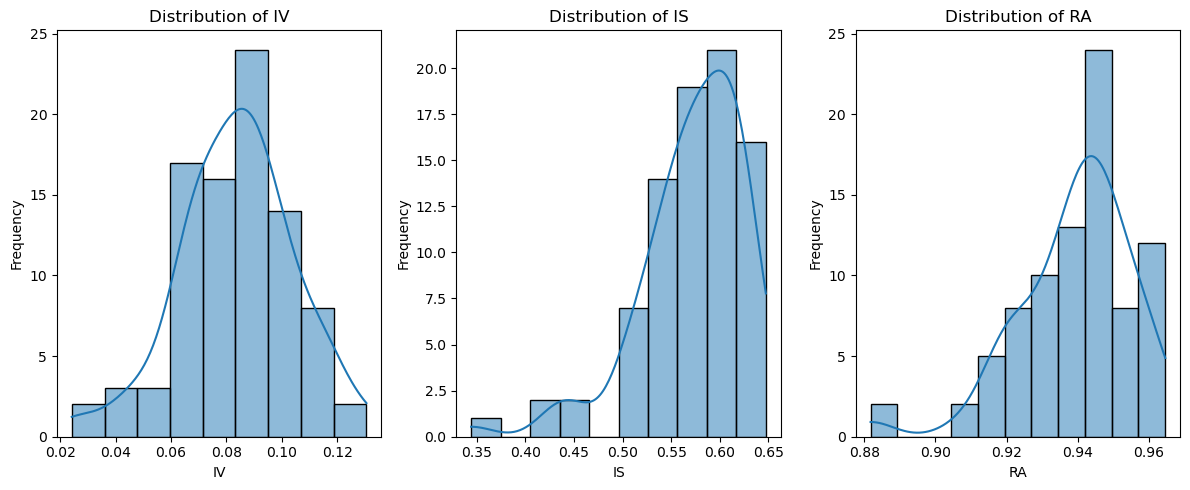

In [88]:
# distribution of IV, IS, and RA
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
sns.histplot(merged_data['IV'].dropna(), kde=True)
plt.title('Distribution of IV')
plt.xlabel('IV')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(merged_data['IS'].dropna(), kde=True)
plt.title('Distribution of IS')
plt.xlabel('IS')
plt.ylabel('Frequency')
 
plt.subplot(1, 3, 3)
sns.histplot(merged_data['RA'].dropna(), kde=True)
plt.title('Distribution of RA')
plt.xlabel('RA')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [89]:
# compare the variables between ITA and UK
iv_ttest = stats.ttest_ind(merged_data[merged_data['location'] == 'ITA']['IV'], merged_data[merged_data['location'] == 'UK']['IV'], nan_policy='omit')
is_utest = stats.mannwhitneyu(merged_data[merged_data['location'] == 'ITA']['IS'], merged_data[merged_data['location'] == 'UK']['IS'], nan_policy='omit')
ra_utest = stats.mannwhitneyu(merged_data[merged_data['location'] == 'ITA']['RA'], merged_data[merged_data['location'] == 'UK']['RA'], nan_policy='omit')

In [90]:
print('Test results for IV by location:', iv_ttest)
print('Test results for IS by location:', is_utest)
print('Test results for RA by location:', ra_utest)

Test results for IV by location: TtestResult(statistic=-1.7772445658632352, pvalue=0.07902284498496115, df=87.0)
Test results for IS by location: MannwhitneyuResult(statistic=869.5, pvalue=0.6178431739272754)
Test results for RA by location: MannwhitneyuResult(statistic=916.5, pvalue=0.5474926482394891)


------------------------

_Midsleep vs days after flight_

In [91]:
# n of days by day_after_flight
count_day_after_flight = df['day_after_flight'].value_counts()

In [92]:
# filter the data by the days after the flight (8)
midsleep_bydays_after_flight = df[df['day_after_flight'] <= 14]

In [93]:
# group by location
midsleep_bydays_after_flight_uk = midsleep_bydays_after_flight[midsleep_bydays_after_flight['location'] == 'UK']
midsleep_bydays_after_flight_ita = midsleep_bydays_after_flight[midsleep_bydays_after_flight['location'] == 'ITA']

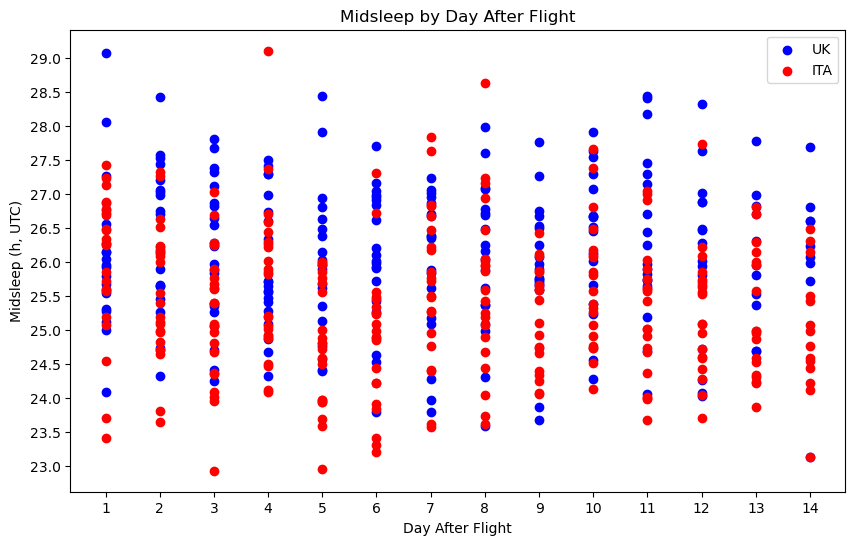

In [94]:
plt.figure(figsize=(10, 6))
plt.scatter(midsleep_bydays_after_flight_uk['day_after_flight'], midsleep_bydays_after_flight_uk['midsleep_h_UTC'], label='UK', color='blue')
plt.scatter(midsleep_bydays_after_flight_ita['day_after_flight'], midsleep_bydays_after_flight_ita['midsleep_h_UTC'], label='ITA', color='red')
plt.xlabel('Day After Flight')
plt.ylabel('Midsleep (h, UTC)')
plt.gca().xaxis.set_major_locator(MultipleLocator(1))
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.title('Midsleep by Day After Flight')
plt.legend()
plt.show()

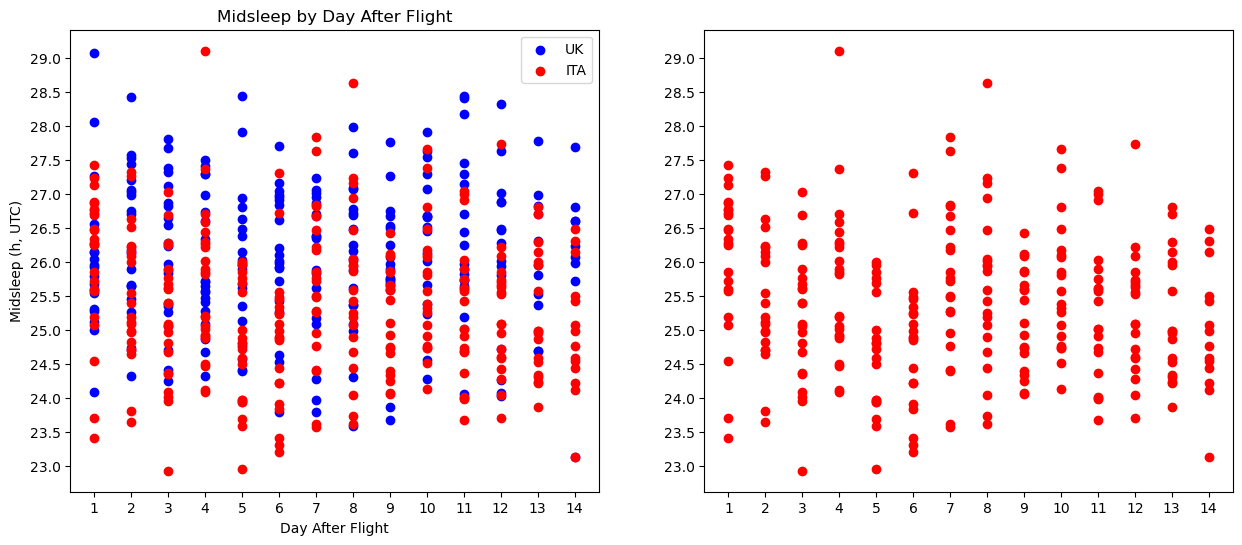

In [95]:
#show the outliers in the midsleep by day after flight day 6, 7, 8 
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.scatter(midsleep_bydays_after_flight_uk['day_after_flight'], midsleep_bydays_after_flight_uk['midsleep_h_UTC'], label='UK', color='blue')
plt.scatter(midsleep_bydays_after_flight_ita['day_after_flight'], midsleep_bydays_after_flight_ita['midsleep_h_UTC'], label='ITA', color='red')
plt.xlabel('Day After Flight')
plt.ylabel('Midsleep (h, UTC)')
plt.gca().xaxis.set_major_locator(MultipleLocator(1))
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.title('Midsleep by Day After Flight')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(midsleep_bydays_after_flight_ita['day_after_flight'], midsleep_bydays_after_flight_ita['midsleep_h_UTC'], label='UK', color='red')
plt.gca().xaxis.set_major_locator(MultipleLocator(1))
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.show()

In [96]:
# Fit a mixed-effects model using day_after_flight as a continuous variable
model_1 = smf.mixedlm(formula='midsleep_h_UTC ~ day_after_flight', data=midsleep_bydays_after_flight, groups=midsleep_bydays_after_flight['day_after_flight']).fit()

model_continuous_summary = model_1.summary()
model_continuous_summary

<class 'statsmodels.iolib.summary2.Summary'>
"""
           Mixed Linear Model Regression Results
============================================================
Model:            MixedLM Dependent Variable: midsleep_h_UTC
No. Observations: 530     Method:             REML          
No. Groups:       14      Scale:              1.2482        
Min. group size:  23      Log-Likelihood:     -817.2738     
Max. group size:  43      Converged:          Yes           
Mean group size:  37.9                                      
------------------------------------------------------------
                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept        25.843    0.118 218.559 0.000 25.611 26.074
day_after_flight -0.020    0.015  -1.370 0.171 -0.048  0.009
Group Var         0.012    0.016                            
============================================================

"""

In [97]:
# Shapiro-Wilk test for the residuals   
shapiro_residuals = stats.shapiro(model_1.resid)

print('Shapiro test for the residuals:', shapiro_residuals)

Shapiro test for the residuals: ShapiroResult(statistic=0.9961963365042411, pvalue=0.2355556857416043)


In [98]:
residuals = model_1.resid 
predicted = model_1.fittedvalues

In [99]:
# Breusch-Pagan test for homoscedasticity
bp_test = het_breuschpagan(residuals, model_1.model.exog)

# results of the Breusch-Pagan test
bp_stat, bp_pval, _, _ = bp_test
print(f'Breusch-Pagan statistic: {bp_stat}, p-value: {bp_pval}')
if bp_pval > 0.05:
    print('The residuals are homoscedastic (fail to reject H0).')
else:
    print('The residuals are heteroscedastic (reject H0).')

Breusch-Pagan statistic: 0.011568068887095606, p-value: 0.9143487283343523
The residuals are homoscedastic (fail to reject H0).


In [100]:
# Durbin-Watson test for autocorrelation
durbin_watson_test = durbin_watson(residuals)

print('Durbin-Watson test:', durbin_watson_test)

Durbin-Watson test: 1.1861334729587507


In [101]:
# Fit a mixed-effects model including both day_after_flight and location as predictors and adding an interaction term
model_2 = smf.mixedlm(formula='midsleep_h_UTC ~ day_after_flight*location', data=midsleep_bydays_after_flight, groups=midsleep_bydays_after_flight['day_after_flight']).fit()

model_interaction_summary = model_2.summary()
model_interaction_summary

<class 'statsmodels.iolib.summary2.Summary'>
"""
                   Mixed Linear Model Regression Results
===========================================================================
Model:                 MixedLM      Dependent Variable:      midsleep_h_UTC
No. Observations:      530          Method:                  REML          
No. Groups:            14           Scale:                   1.1056        
Min. group size:       23           Log-Likelihood:          -789.5176     
Max. group size:       43           Converged:               Yes           
Mean group size:       37.9                                                
---------------------------------------------------------------------------
                                Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------
Intercept                       25.576    0.149 171.159 0.000 25.283 25.869
location[T.UK]                   0.516    0.189   2.730 0.006  0.146  0.887
day_after_flight                -0.031    0.018  -1.708 0.088 -0.066  0.005
day_after_flight:location[T.UK]  0.033    0.024   1.388 0.165 -0.014  0.079
Group Var                        0.018    0.018                            
===========================================================================

"""

In [102]:
# Shapiro-Wilk test for the residuals   
shapiro_residuals2 = stats.shapiro(model_2.resid)

print('Shapiro test for the residuals:', shapiro_residuals2)

Shapiro test for the residuals: ShapiroResult(statistic=0.9979200912522094, pvalue=0.7685808083580943)


In [103]:
residuals2 = model_2.resid 
predicted2 = model_2.fittedvalues

In [104]:
# Breusch-Pagan test for homoscedasticity
bp_test2 = het_breuschpagan(residuals2, model_2.model.exog)

# results of the Breusch-Pagan test
bp_stat2, bp_pval2, _, _ = bp_test2
print(f'Breusch-Pagan statistic: {bp_stat2}, p-value: {bp_pval2}')
if bp_pval2 > 0.05:
    print('The residuals are homoscedastic (fail to reject H0).')
else:
    print('The residuals are heteroscedastic (reject H0).')

Breusch-Pagan statistic: 2.3819434224270317, p-value: 0.4970046994929155
The residuals are homoscedastic (fail to reject H0).


In [105]:
# Durbin-Watson test for autocorrelation
durbin_watson_test2 = durbin_watson(residuals2)

print('Durbin-Watson test:', durbin_watson_test2)

Durbin-Watson test: 1.3386501897543392


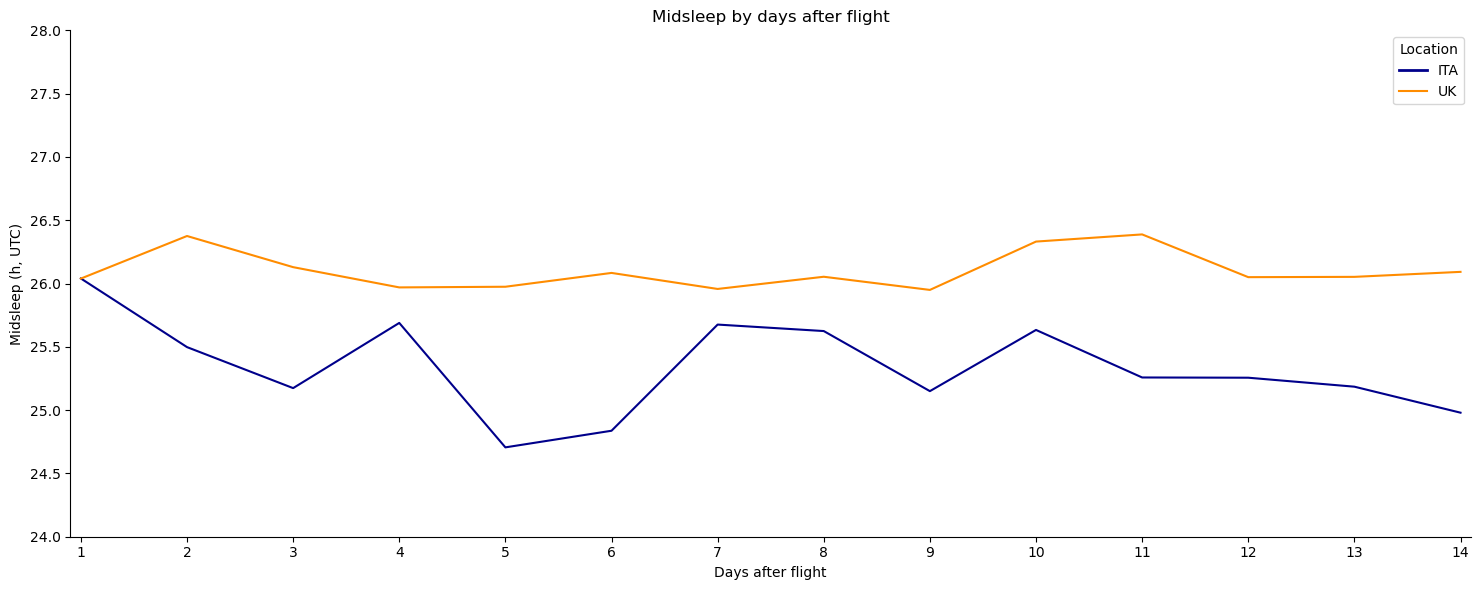

In [106]:
plt.figure(figsize=(15, 6))
sns.lineplot(x='day_after_flight', y='midsleep_h_UTC', hue='location', data=midsleep_bydays_after_flight, palette=['darkblue', 'darkorange'], errorbar=None)
plt.title('Midsleep by days after flight')
plt.xlabel('Days after flight')
plt.ylabel('Midsleep (h, UTC)')
plt.legend(title='Location', labels=['ITA', 'UK'], loc='upper right', handles=[plt.Line2D([0], [0], color='darkblue', lw=2), plt.Line2D([0], [0], color='darkorange')])
plt.grid(False)
plt.xticks()
plt.tight_layout()
plt.xlim(0.9,14.1)
plt.ylim(24, 28)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.gca().xaxis.set_major_locator(MultipleLocator(1)) 

plt.show()

In [107]:
# Fit a mixed-effects model including both day_after_flight, location, seasons, DST as predictors
model_3 = smf.mixedlm(formula='midsleep_h_UTC ~ day_after_flight + C(location) + photoperiod + DST_0 + C(location)*photoperiod', data=midsleep_bydays_after_flight, groups=midsleep_bydays_after_flight['day_after_flight']).fit()

model_3_summary = model_3.summary()
model_3_summary

<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Mixed Linear Model Regression Results
========================================================================
Model:                MixedLM     Dependent Variable:     midsleep_h_UTC
No. Observations:     530         Method:                 REML          
No. Groups:           14          Scale:                  0.8823        
Min. group size:      23          Log-Likelihood:         -734.6556     
Max. group size:      43          Converged:              Yes           
Mean group size:      37.9                                              
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                     25.987    0.358 72.574 0.000 25.285 26.688
C(location)[T.UK]              1.430    0.377  3.793 0.000  0.691  2.169
day_after_flight              -0.021    0.015 -1.382 0.167 -0.050  0.009
photoperiod                   -0.005    0.032 -0.158 0.875 -0.067  0.057
C(location)[T.UK]:photoperiod -0.062    0.031 -1.978 0.048 -0.124 -0.001
DST_0                         -0.758    0.131 -5.791 0.000 -1.014 -0.501
Group Var                      0.025    0.021                           
========================================================================

"""

In [108]:
coef_df3 = pd.DataFrame({'coef': model_3.params.values, 'p-value': model_3.pvalues.values, '0.025': model_3.conf_int()[0], '0.975': model_3.conf_int()[1]})
coef_df3

,coef,p-value,0.025,0.975
Intercept,25.986677,0.000000e+00,25.284873,26.688480
C(location)[T.UK],1.430313,1.486843e-04,0.691275,2.169351
day_after_flight,-0.020654,1.671106e-01,-0.049955,0.008647
photoperiod,-0.005014,8.746384e-01,-0.067304,0.057276
C(location)[T.UK]:photoperiod,-0.062192,4.789541e-02,-0.123807,-0.000576
DST_0,-0.757580,7.009411e-09,-1.013996,-0.501163
Group Var,0.028579,2.023867e-01,-0.015361,0.072519


In [109]:
#drop intercept from coef_df
coef_df3 = coef_df3.drop(index='Intercept')   
coef_df3 = coef_df3.drop('Group Var', axis=0)

C:\Users\gg00642\AppData\Local\Temp\ipykernel_18348\242236948.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['Location[T.UK]', 'Days after flight', 'Photoperiod', 'Location[T.UK]*Photoperiod', 'Time shift[T.ST]'])


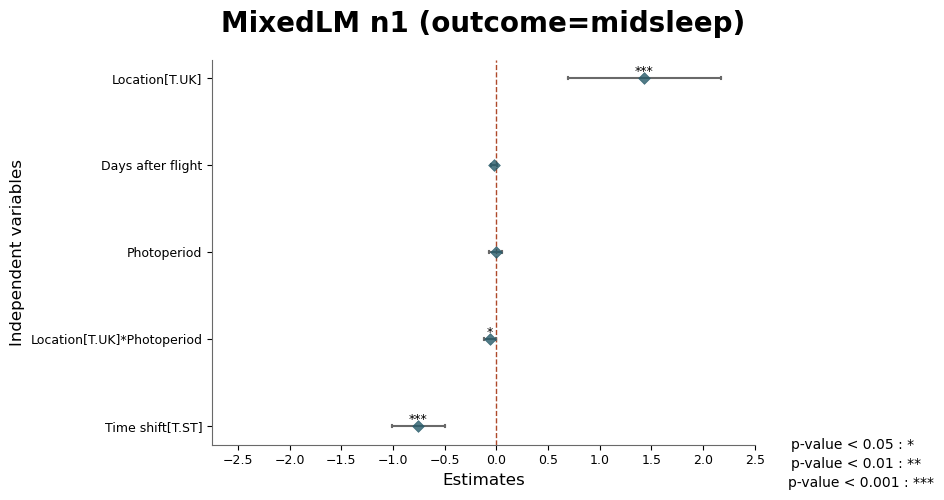

In [110]:
# initialize the matplotlib figure
plt.figure(figsize=(7, 5))
#sns.set_theme(style="whitegrid", rc={"axes.grid": False})  # set the style of the plot and remove the grid
#sns.set_palette("Paired")  # set the color palette of the plot
plt.axvline(x=0, color='#ae492a', linewidth=1, linestyle='--')  # add a vertical line at 0

ax = sns.stripplot(x="coef", y=coef_df3.index, data=coef_df3, size=6, marker='D', linewidth=0.5, color='#265a69', edgecolor='#265a69', alpha=0.8)
# add the 0.025 and 0.975 confidence intervals as T-shaped lines
for i in range(coef_df3.shape[0]):
    plt.plot([coef_df3['0.025'].iloc[i], coef_df3['0.975'].iloc[i]], [i, i], color='dimgray', linewidth=1.5)
    plt.plot([coef_df3['0.025'].iloc[i], coef_df3['0.025'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)
    plt.plot([coef_df3['0.975'].iloc[i], coef_df3['0.975'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)

# add the significance as *** for p-value < 0.001, ** for p-value < 0.01, * for p-value < 0.05 close to the variable name
for i in range(coef_df3.shape[0]):
    if coef_df3['p-value'].iloc[i] < 0.001:
        plt.text(coef_df3['coef'].iloc[i], i, '***', ha='center', va='bottom', fontsize=9)
    elif coef_df3['p-value'].iloc[i] < 0.01:
        plt.text(coef_df3['coef'].iloc[i], i, '**', ha='center', va='bottom', fontsize=9)
    elif coef_df3['p-value'].iloc[i] < 0.05:
        plt.text(coef_df3['coef'].iloc[i], i, '*', ha='center', va='bottom', fontsize=9) 

# add a legend of the significance at the top of the plot
plt.text(1.196, -0.1, 'p-value < 0.001 : ***', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.190, -0.05, 'p-value < 0.01 : ** ', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.189, -0.00, 'p-value < 0.05 : *  ', ha='center', va='center', fontsize=10, transform=ax.transAxes)

ax.set_title('MixedLM n1 (outcome=midsleep)', fontsize=20, fontweight='bold', pad=20)
plt.xlim(-2.75, 2.5)
plt.gca().xaxis.set_major_locator(MultipleLocator(0.5))
ax.spines['left'].set_color('dimgray')
ax.spines['bottom'].set_color('dimgray')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
ax.set_xlabel('Estimates', fontsize=12)
ax.set_ylabel('Independent variables', fontsize=12)  # add y-axis title
# remove spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


ax.set_yticklabels(['Location[T.UK]', 'Days after flight', 'Photoperiod', 'Location[T.UK]*Photoperiod', 'Time shift[T.ST]'])

plt.show()

In [111]:
# Shapiro-Wilk test for the residuals   
shapiro_residuals3 = stats.shapiro(model_3.resid)

print('Shapiro test for the residuals:', shapiro_residuals3)

Shapiro test for the residuals: ShapiroResult(statistic=0.9953735016457462, pvalue=0.11650100200563934)


In [112]:
residuals3 = model_3.resid 
predicted3 = model_3.fittedvalues

In [113]:
# Breusch-Pagan test for homoscedasticity
bp_test3 = het_breuschpagan(residuals3, model_3.model.exog)

# results of the Breusch-Pagan test
bp_stat3, bp_pval3, _, _ = bp_test3
print(f'Breusch-Pagan statistic: {bp_stat3}, p-value: {bp_pval3}')
if bp_pval3 > 0.05:
    print('The residuals are homoscedastic (fail to reject H0).')
else:
    print('The residuals are heteroscedastic (reject H0).')

Breusch-Pagan statistic: 0.9972693616982731, p-value: 0.9627857172487919
The residuals are homoscedastic (fail to reject H0).


In [114]:
# Durbin-Watson test for autocorrelation
durbin_watson_test2 = durbin_watson(residuals2)

print('Durbin-Watson test:', durbin_watson_test2)

Durbin-Watson test: 1.3386501897543392


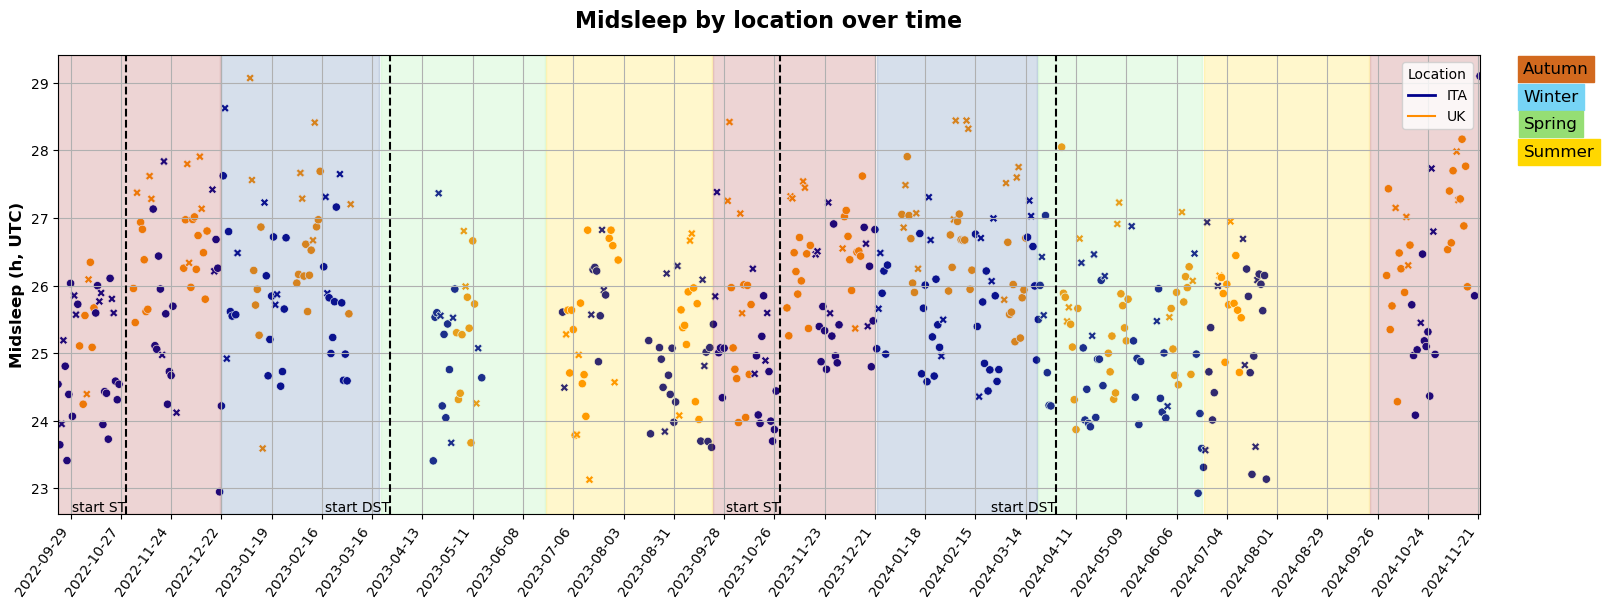

In [115]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='midsleep_h_UTC', hue='location', style='weekday_type', data=midsleep_bydays_after_flight, palette=['darkblue', 'darkorange'])
plt.title('Midsleep by location over time', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Midsleep (h, UTC)', fontsize=12, fontweight='bold')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min(), df['date'].max())
plt.legend(title='Location', labels=['ITA', 'UK'], loc='upper right', handles=[plt.Line2D([0], [0], color='darkblue', lw=2), plt.Line2D([0], [0], color='darkorange')])
plt.gca().xaxis.set_major_locator(MultipleLocator(28)) #get the current axis = gca

# vertical bar to indicate the start of the DST and the start of the ST 
plt.axvline(x=pd.to_datetime('2022-10-30'), color='black', linestyle='--')
plt.text(pd.to_datetime('2022-10-30'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-10-29'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-10-29'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-03-26'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-03-26'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-03-31'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-03-31'), plt.ylim()[0], 'start DST', ha='right', va='bottom')

# define seasons
seasons = [
    ('2022-09-22', '2022-12-21', 'brown'),  # Autumn
    ('2022-12-22', '2023-03-20', '#335f9e'),  # Winter
    ('2023-03-21', '2023-06-20', 'lightgreen'), # Spring
    ('2023-06-21', '2023-09-21', 'gold'),     # Summer
    ('2023-09-22', '2023-12-21', 'brown'),  # Autumn
    ('2023-12-22', '2024-03-20', '#335f9e'),  # Winter
    ('2024-03-21', '2024-06-20', 'lightgreen'), # Spring
    ('2024-06-21', '2024-09-21', 'gold'),     # Summer
    ('2024-09-22', '2024-12-21', 'brown'),  # Autumn
]

# apply the background color for each season
for start, end, color in seasons:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.2)

plt.annotate('Summer', xy=(1.0555, 0.79), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='gold')
plt.annotate('Autumn', xy=(1.0535, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='chocolate')
plt.annotate('Winter', xy=(1.05, 0.91), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#76d4f5')
plt.annotate('Spring', xy=(1.0499, 0.85), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#95de74')

# mean of the phase for the two locations
#plt.axhline(y=df[df['location'] == 'ITA']['phase'].mean(), color='darkblue', linestyle='--', label='Mean ITA')
#plt.text(plt.xlim()[1], df[df['location'] == 'ITA']['phase'].mean(), 'Mean ITA', ha='right', va='bottom')
#plt.axhline(y=df[df['location'] == 'UK']['phase'].mean(), color='darkorange', linestyle='--', label='Mean UK')
#plt.text(plt.xlim()[1], df[df['location'] == 'UK']['phase'].mean(), 'Mean UK', ha='right', va='bottom')

plt.show()

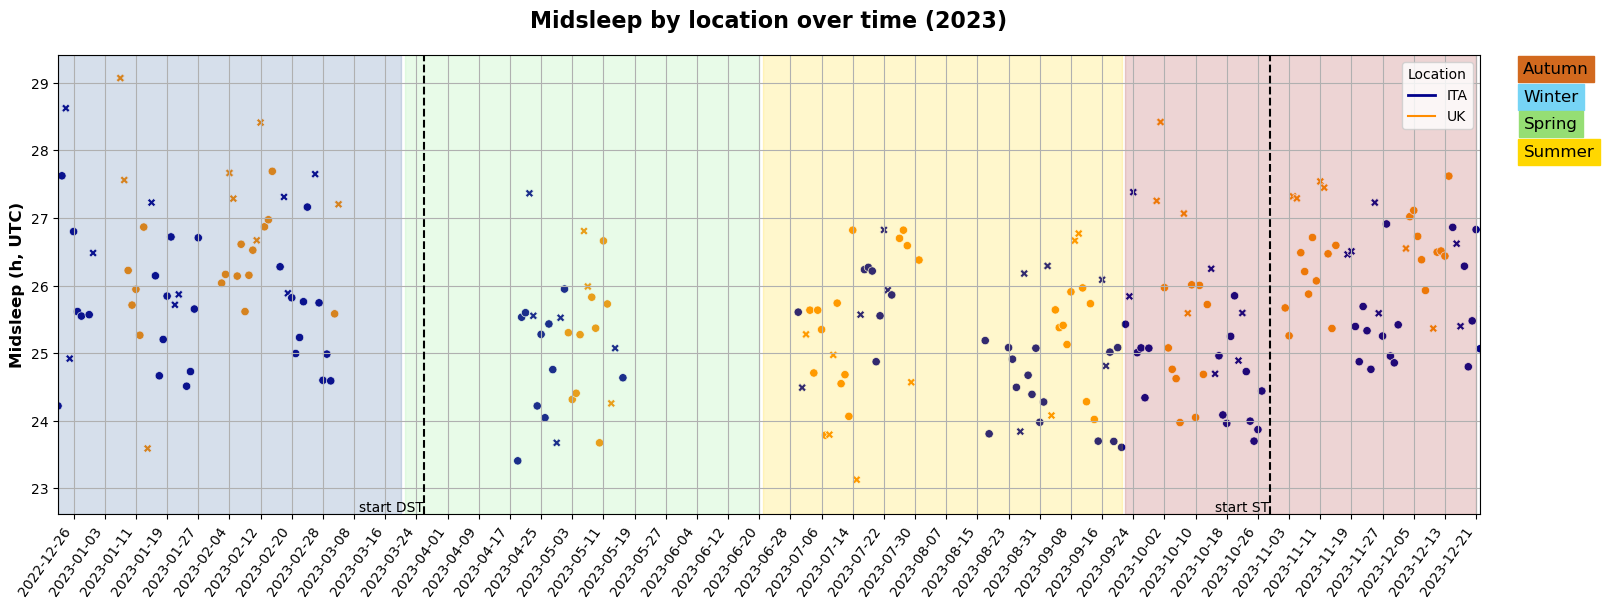

In [116]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='midsleep_h_UTC', hue='location', style='weekday_type', data=midsleep_bydays_after_flight, palette=['darkblue', 'darkorange'])
plt.title('Midsleep by location over time (2023)', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Midsleep (h, UTC)', fontsize=12, fontweight='bold')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min() + pd.DateOffset(months=3), df['date'].min() + pd.DateOffset(months=15))
plt.legend(title='Location', labels=['ITA', 'UK'], loc='upper right', handles=[plt.Line2D([0], [0], color='darkblue', lw=2), plt.Line2D([0], [0], color='darkorange')])
plt.gca().xaxis.set_major_locator(MultipleLocator(8)) #get the current axis = gca

# vertical bar to indicate the start of the DST and the start of the ST 
#plt.axvline(x=pd.to_datetime('2022-10-30'), color='black', linestyle='--')
#plt.text(pd.to_datetime('2022-10-30'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-10-29'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-10-29'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
#plt.axvline(x=pd.to_datetime('2024-10-27'), color='black', linestyle='--')
#plt.text(pd.to_datetime('2024-10-27'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-03-26'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-03-26'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
#plt.axvline(x=pd.to_datetime('2024-03-31'), color='black', linestyle='--')
#plt.text(pd.to_datetime('2024-03-31'), plt.ylim()[0], 'start DST', ha='right', va='bottom')

# define seasons
seasons = [
    ('2022-09-22', '2022-12-21', 'brown'),  # Autumn
    ('2022-12-22', '2023-03-20', '#335f9e'),  # Winter
    ('2023-03-21', '2023-06-20', 'lightgreen'), # Spring
    ('2023-06-21', '2023-09-21', 'gold'),     # Summer
    ('2023-09-22', '2023-12-21', 'brown'),  # Autumn
    ('2023-12-22', '2024-03-20', '#335f9e'),  # Winter
    ('2024-03-21', '2024-06-20', 'lightgreen'), # Spring
    ('2024-06-21', '2024-09-21', 'gold'),     # Summer
    ('2024-09-22', '2024-12-21', 'brown'),  # Autumn
]

# apply the background color for each season
for start, end, color in seasons:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.2)

plt.annotate('Summer', xy=(1.0555, 0.79), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='gold')
plt.annotate('Autumn', xy=(1.0535, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='chocolate')
plt.annotate('Winter', xy=(1.05, 0.91), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#76d4f5')
plt.annotate('Spring', xy=(1.0499, 0.85), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#95de74')

# mean of the phase for the two locations
#plt.axhline(y=df[df['location'] == 'ITA']['phase'].mean(), color='darkblue', linestyle='--', label='Mean ITA')
#plt.text(plt.xlim()[1], df[df['location'] == 'ITA']['phase'].mean(), 'Mean ITA', ha='right', va='bottom')
#plt.axhline(y=df[df['location'] == 'UK']['phase'].mean(), color='darkorange', linestyle='--', label='Mean UK')
#plt.text(plt.xlim()[1], df[df['location'] == 'UK']['phase'].mean(), 'Mean UK', ha='right', va='bottom')

plt.show()

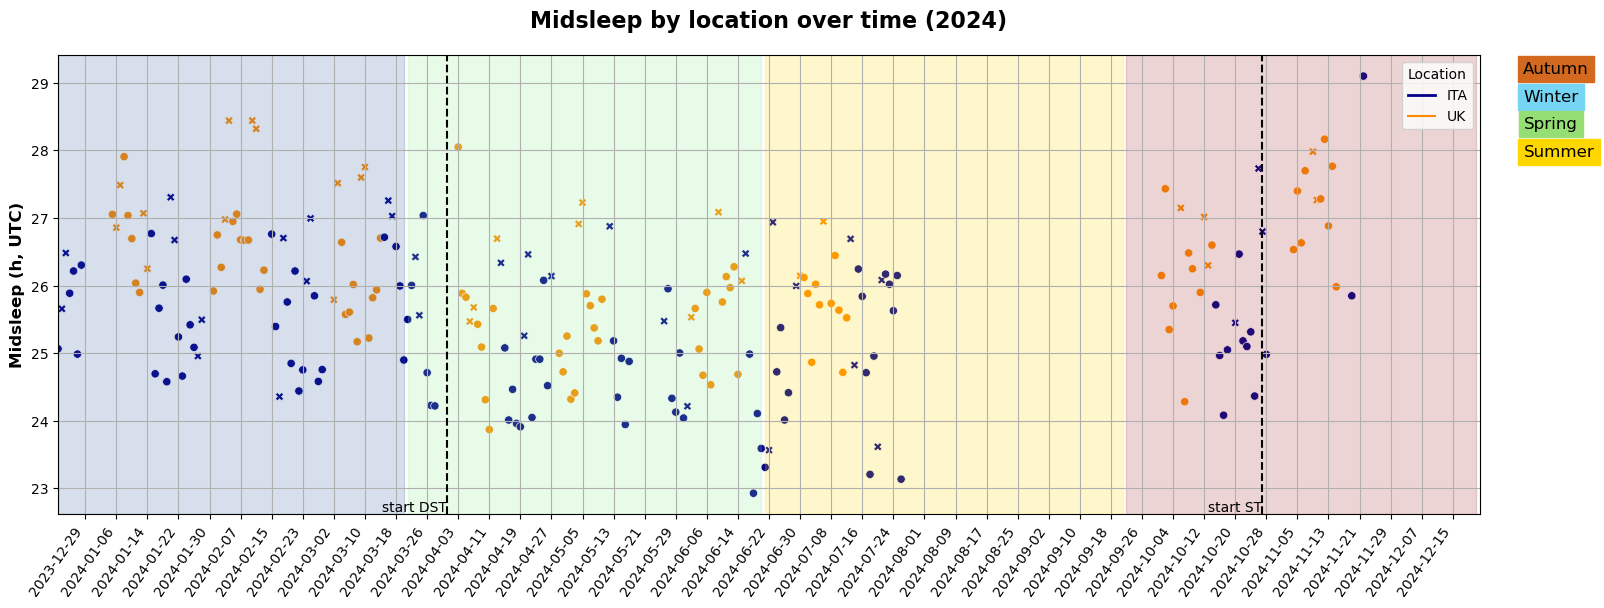

In [117]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='midsleep_h_UTC', hue='location', style='weekday_type', data=midsleep_bydays_after_flight, palette=['darkblue', 'darkorange'])
plt.title('Midsleep by location over time (2024)', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Midsleep (h, UTC)', fontsize=12, fontweight='bold')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min() + pd.DateOffset(months=15), df['date'].min() + pd.DateOffset(months=27))
plt.legend(title='Location', labels=['ITA', 'UK'], loc='upper right', handles=[plt.Line2D([0], [0], color='darkblue', lw=2), plt.Line2D([0], [0], color='darkorange')])
plt.gca().xaxis.set_major_locator(MultipleLocator(8)) #get the current axis = gca

# vertical bar to indicate the start of the DST and the start of the ST 
#plt.axvline(x=pd.to_datetime('2022-10-30'), color='black', linestyle='--')
#plt.text(pd.to_datetime('2022-10-30'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
#plt.axvline(x=pd.to_datetime('2023-10-29'), color='black', linestyle='--')
#plt.text(pd.to_datetime('2023-10-29'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-10-27'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-10-27'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
#plt.axvline(x=pd.to_datetime('2023-03-26'), color='black', linestyle='--')
#plt.text(pd.to_datetime('2023-03-26'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-03-31'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-03-31'), plt.ylim()[0], 'start DST', ha='right', va='bottom')

# define seasons
seasons = [
    ('2022-09-22', '2022-12-21', 'brown'),  # Autumn
    ('2022-12-22', '2023-03-20', '#335f9e'),  # Winter
    ('2023-03-21', '2023-06-20', 'lightgreen'), # Spring
    ('2023-06-21', '2023-09-21', 'gold'),     # Summer
    ('2023-09-22', '2023-12-21', 'brown'),  # Autumn
    ('2023-12-22', '2024-03-20', '#335f9e'),  # Winter
    ('2024-03-21', '2024-06-20', 'lightgreen'), # Spring
    ('2024-06-21', '2024-09-21', 'gold'),     # Summer
    ('2024-09-22', '2024-12-21', 'brown'),  # Autumn
]

# apply the background color for each season
for start, end, color in seasons:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.2)

plt.annotate('Summer', xy=(1.0555, 0.79), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='gold')
plt.annotate('Autumn', xy=(1.0535, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='chocolate')
plt.annotate('Winter', xy=(1.05, 0.91), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#76d4f5')
plt.annotate('Spring', xy=(1.0499, 0.85), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#95de74')

# mean of the phase for the two locations
#plt.axhline(y=df[df['location'] == 'ITA']['phase'].mean(), color='darkblue', linestyle='--', label='Mean ITA')
#plt.text(plt.xlim()[1], df[df['location'] == 'ITA']['phase'].mean(), 'Mean ITA', ha='right', va='bottom')
#plt.axhline(y=df[df['location'] == 'UK']['phase'].mean(), color='darkorange', linestyle='--', label='Mean UK')
#plt.text(plt.xlim()[1], df[df['location'] == 'UK']['phase'].mean(), 'Mean UK', ha='right', va='bottom')

plt.show()

_Phase by location, time, DST and season_

In [118]:
# filter the data by the days after the flight (15)
phase_bydays_after_flight = df[df['day_after_flight'] <= 14]

In [119]:
# location coded as 0=ITA, 1=UK
#phase_bydays_after_flight['location'] = phase_bydays_after_flight['location'].map({'ITA': 0, 'UK': 1})

In [120]:
# converting date to numerical values (days since the start of the observation period)
#data_phase['date_numeric'] = (pd.to_datetime(data_phase['date']) - pd.to_datetime(data_phase['date']).min()).dt.days

In [121]:
# test the skewness of the phase data
skewness = skew(phase_bydays_after_flight['phase'])

print(f"Index of skewness: {skewness}")

Index of skewness: 0.5266008133755986


In [122]:
# test the correlations between predictors
correlation_matrix = phase_bydays_after_flight[['photoperiod', 'day_after_flight']].corr()

correlation_matrix

,photoperiod,day_after_flight
photoperiod,1.000000,-0.042779
day_after_flight,-0.042779,1.000000


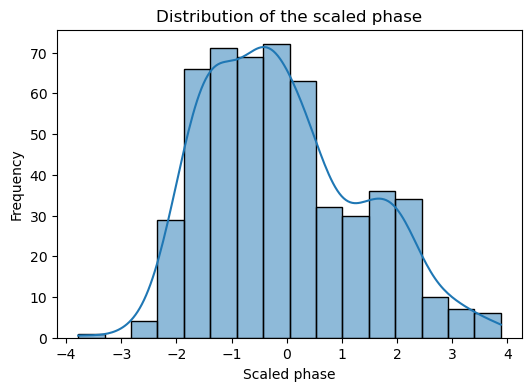

In [123]:
#plot the distribution
plt.figure(figsize=(6, 4))
sns.histplot(phase_bydays_after_flight['phase'], kde=True)
plt.title('Distribution of the scaled phase')
plt.xlabel('Scaled phase')
plt.ylabel('Frequency')
plt.show()

In [124]:
phase_data = phase_bydays_after_flight['phase'].values.reshape(-1, 1)

# apply the Yeo-Johnson transformation
pt = PowerTransformer(method='yeo-johnson')
phase_transformed = pt.fit_transform(phase_data)

In [125]:
# add the transformed phase to the dataframe 
phase_bydays_after_flight['phase_transformed'] = phase_transformed

C:\Users\gg00642\AppData\Local\Temp\ipykernel_18348\2837614658.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phase_bydays_after_flight['phase_transformed'] = phase_transformed


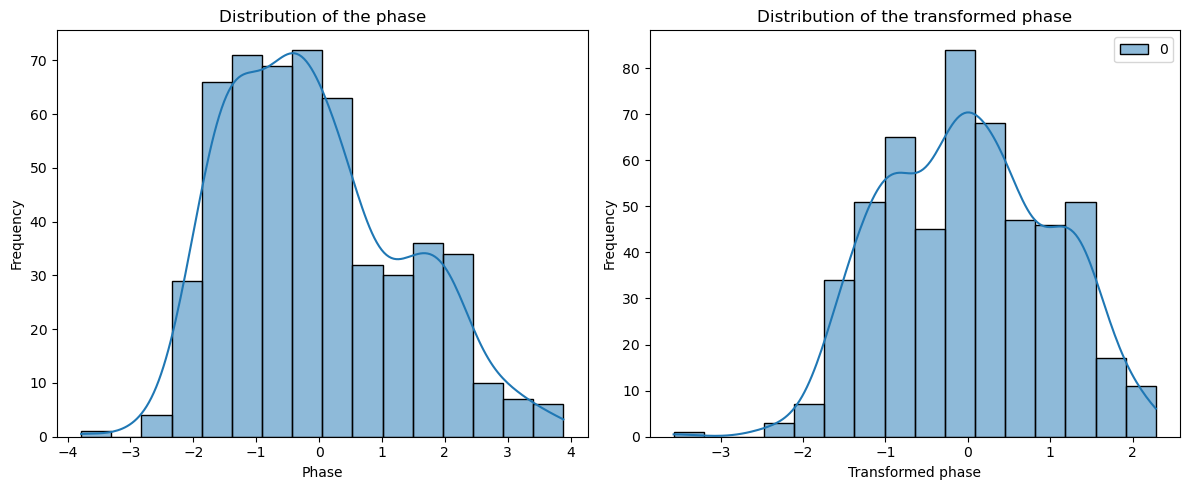

In [126]:
# plot the distribution of the transformed phase and the original phase
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(phase_bydays_after_flight['phase'], kde=True)
plt.title('Distribution of the phase')
plt.xlabel('Phase')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(phase_transformed, kde=True)
plt.title('Distribution of the transformed phase')
plt.xlabel('Transformed phase')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [127]:
# Shapiro-Wilk test for the transformed phase
shapiro_test4 = stats.shapiro(phase_bydays_after_flight['phase_transformed'])
shapiro_test4

ShapiroResult(statistic=0.9866183305993964, pvalue=8.756555313651849e-05)

In [128]:
# Modello senza trasformazione
model_4 = smf.mixedlm('phase ~ day_after_flight + C(location) + photoperiod + C(DST_0) + C(location)*photoperiod',phase_bydays_after_flight, groups=phase_bydays_after_flight['day_after_flight'], re_formula="~1").fit()

model_4_summary = model_4.summary()
model_4_summary

<class 'statsmodels.iolib.summary2.Summary'>
"""
                  Mixed Linear Model Regression Results
=========================================================================
Model:                  MixedLM       Dependent Variable:       phase    
No. Observations:       530           Method:                   REML     
No. Groups:             14            Scale:                    0.8241   
Min. group size:        23            Log-Likelihood:           -715.9576
Max. group size:        43            Converged:                Yes      
Mean group size:        37.9                                             
-------------------------------------------------------------------------
                              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                     -5.438    0.343 -15.842 0.000 -6.111 -4.765
C(location)[T.UK]              1.184    0.364   3.249 0.001  0.470  1.898
C(DST_0)[T.1]                 -0.687    0.126  -5.437 0.000 -0.935 -0.440
day_after_flight              -0.009    0.014  -0.633 0.527 -0.035  0.018
photoperiod                    0.459    0.031  14.932 0.000  0.398  0.519
C(location)[T.UK]:photoperiod -0.022    0.030  -0.722 0.471 -0.081  0.038
Group Var                      0.018    0.018                            
=========================================================================

"""

In [129]:
coef_df4 = pd.DataFrame({'coef': model_4.params.values, 'p-value': model_4.pvalues.values, '0.025': model_4.conf_int()[0], '0.975': model_4.conf_int()[1]})

In [130]:
# drop info not needed
coef_df4 = coef_df4.drop(index='Intercept')   
coef_df4 = coef_df4.drop('Group Var', axis=0)

C:\Users\gg00642\AppData\Local\Temp\ipykernel_18348\1464405519.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['Location[T.UK]', 'Days after flight', 'Photoperiod', 'Location[T.UK]*Photoperiod', 'Time shift[T.ST]'])


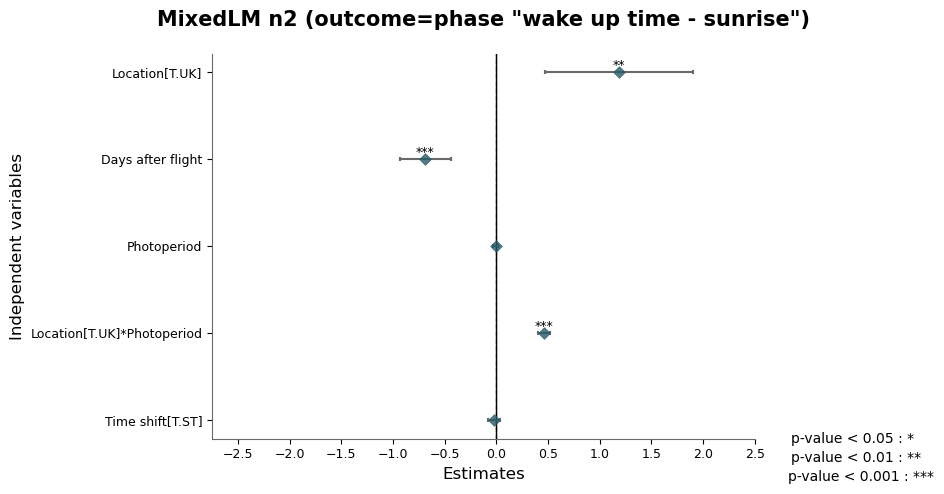

In [131]:
# initialize the matplotlib figure
plt.figure(figsize=(7, 5))
#sns.set_theme(style="whitegrid", rc={"axes.grid": False})  # set the style of the plot and remove the grid
#sns.set_palette("Paired")  # set the color palette of the plot
plt.axvline(x=0, color='#ae492a', linewidth=1, linestyle='--')  # add a vertical line at 0

# add a vertical line at x=0
plt.axvline(x=0, color='black', linewidth=1)

# create a strip plot for the coefficients
ax = sns.stripplot(x='coef', y=coef_df4.index, data=coef_df4, size=6, marker='D', linewidth=0.5, color='#265a69', edgecolor='#265a69', alpha=0.8)

# add the 0.025 and 0.975 confidence intervals as T-shaped lines
for i in range(coef_df4.shape[0]):
    plt.plot([coef_df4['0.025'].iloc[i], coef_df4['0.975'].iloc[i]], [i, i], color='dimgray', linewidth=1.5)
    plt.plot([coef_df4['0.025'].iloc[i], coef_df4['0.025'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)
    plt.plot([coef_df4['0.975'].iloc[i], coef_df4['0.975'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)

# add significance markers
for i in range(coef_df4.shape[0]):
    if coef_df4['p-value'].iloc[i] < 0.001:
        plt.text(coef_df4['coef'].iloc[i], i, '***', ha='center', va='bottom', fontsize=9)
    elif coef_df4['p-value'].iloc[i] < 0.01:
        plt.text(coef_df4['coef'].iloc[i], i, '**', ha='center', va='bottom', fontsize=9)
    elif coef_df4['p-value'].iloc[i] < 0.05:
        plt.text(coef_df4['coef'].iloc[i], i, '*', ha='center', va='bottom', fontsize=9)

# add a legend for significance markers
plt.text(1.196, -0.1, 'p-value < 0.001 : ***', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.190, -0.05, 'p-value < 0.01 : ** ', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.189, -0.00, 'p-value < 0.05 : *  ', ha='center', va='center', fontsize=10, transform=ax.transAxes)

ax.set_title('MixedLM n2 (outcome=phase "wake up time - sunrise")', fontsize=15, fontweight='bold', pad=20)
plt.xlim(-2.75, 2.5)
plt.gca().xaxis.set_major_locator(MultipleLocator(0.5))
ax.spines['left'].set_color('dimgray')
ax.spines['bottom'].set_color('dimgray')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
ax.set_xlabel('Estimates', fontsize=12)
ax.set_ylabel('Independent variables', fontsize=12)  # add y-axis title
# remove spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


ax.set_yticklabels(['Location[T.UK]', 'Days after flight', 'Photoperiod', 'Location[T.UK]*Photoperiod', 'Time shift[T.ST]'])

plt.show()

In [132]:
# Shapiro-Wilk test for the residuals   
shapiro_residuals4 = stats.shapiro(model_4.resid)

print('Shapiro test for the residuals:', shapiro_residuals4)

Shapiro test for the residuals: ShapiroResult(statistic=0.9178703962936741, pvalue=2.229468313969141e-16)


In [133]:
residuals4 = model_4.resid 
predicted4 = model_4.fittedvalues

In [134]:
# Breusch-Pagan test for homoscedasticity
bp_test4 = het_breuschpagan(residuals4, model_4.model.exog)

# results of the Breusch-Pagan test
bp_stat4, bp_pval4, _, _ = bp_test4
print(f'Breusch-Pagan statistic: {bp_stat4}, p-value: {bp_pval4}')
if bp_pval4 > 0.05:
    print('The residuals are homoscedastic (fail to reject H0).')
else:
    print('The residuals are heteroscedastic (reject H0).')

Breusch-Pagan statistic: 7.664976131221265, p-value: 0.17569167276974856
The residuals are homoscedastic (fail to reject H0).


In [135]:
# Durbin-Watson test for autocorrelation
durbin_watson_test4 = durbin_watson(residuals4)

print('Durbin-Watson test:', durbin_watson_test4)

Durbin-Watson test: 1.7427426571726192


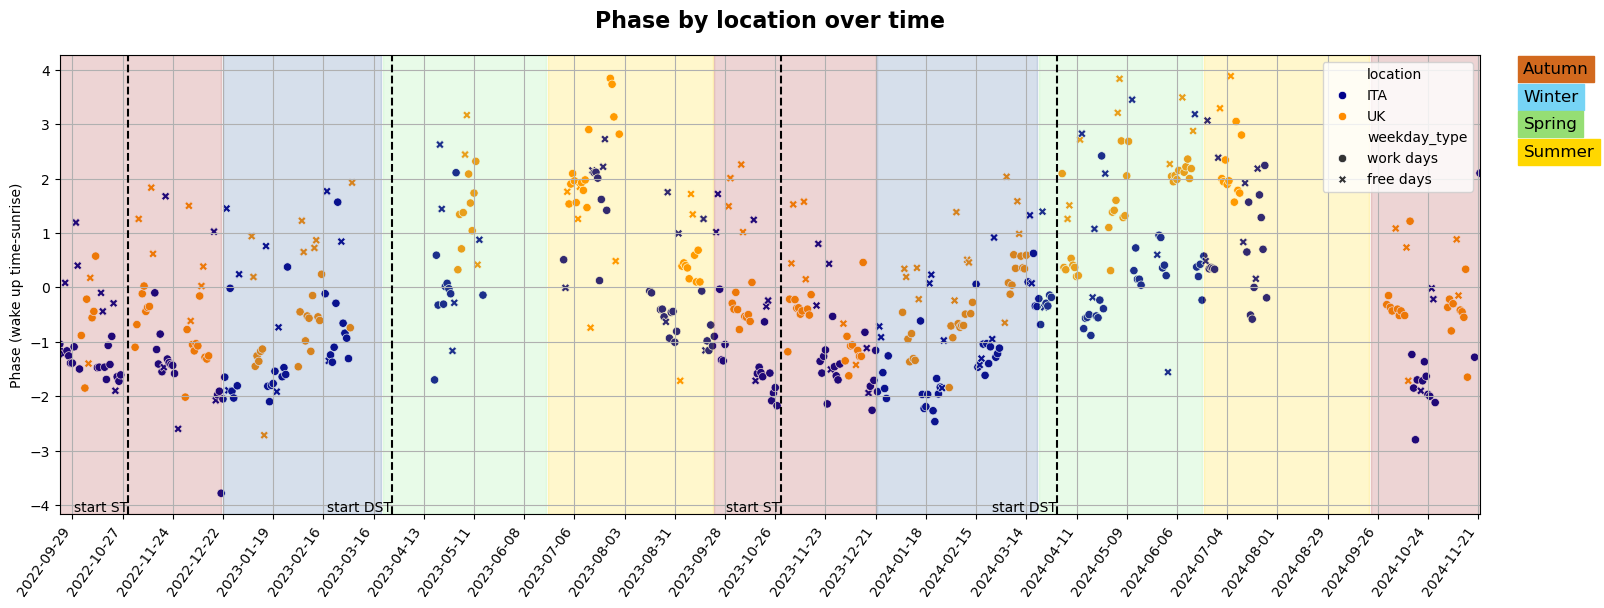

In [136]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='phase', hue='location', style='weekday_type', data=phase_bydays_after_flight, palette=['darkblue', 'darkorange'])
plt.title('Phase by location over time', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Phase (wake up time-sunrise)')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min(), df['date'].max())
plt.gca().xaxis.set_major_locator(MultipleLocator(28)) #get the current axis = gca

# vertical bar to indicate the start of the DST and the start of the ST 
plt.axvline(x=pd.to_datetime('2022-10-30'), color='black', linestyle='--')
plt.text(pd.to_datetime('2022-10-30'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-10-29'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-10-29'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-03-26'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-03-26'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-03-31'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-03-31'), plt.ylim()[0], 'start DST', ha='right', va='bottom')

# define seasons
seasons = [
    ('2022-09-22', '2022-12-21', 'brown'),  # Autumn
    ('2022-12-22', '2023-03-20', '#335f9e'),  # Winter
    ('2023-03-21', '2023-06-20', 'lightgreen'), # Spring
    ('2023-06-21', '2023-09-21', 'gold'),     # Summer
    ('2023-09-22', '2023-12-21', 'brown'),  # Autumn
    ('2023-12-22', '2024-03-20', '#335f9e'),  # Winter
    ('2024-03-21', '2024-06-20', 'lightgreen'), # Spring
    ('2024-06-21', '2024-09-21', 'gold'),     # Summer
    ('2024-09-22', '2024-12-21', 'brown'),  # Autumn
]

# apply the background color for each season
for start, end, color in seasons:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.2)

plt.annotate('Summer', xy=(1.0555, 0.79), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='gold')
plt.annotate('Autumn', xy=(1.0535, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='chocolate')
plt.annotate('Winter', xy=(1.05, 0.91), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#76d4f5')
plt.annotate('Spring', xy=(1.0499, 0.85), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#95de74')

plt.show()

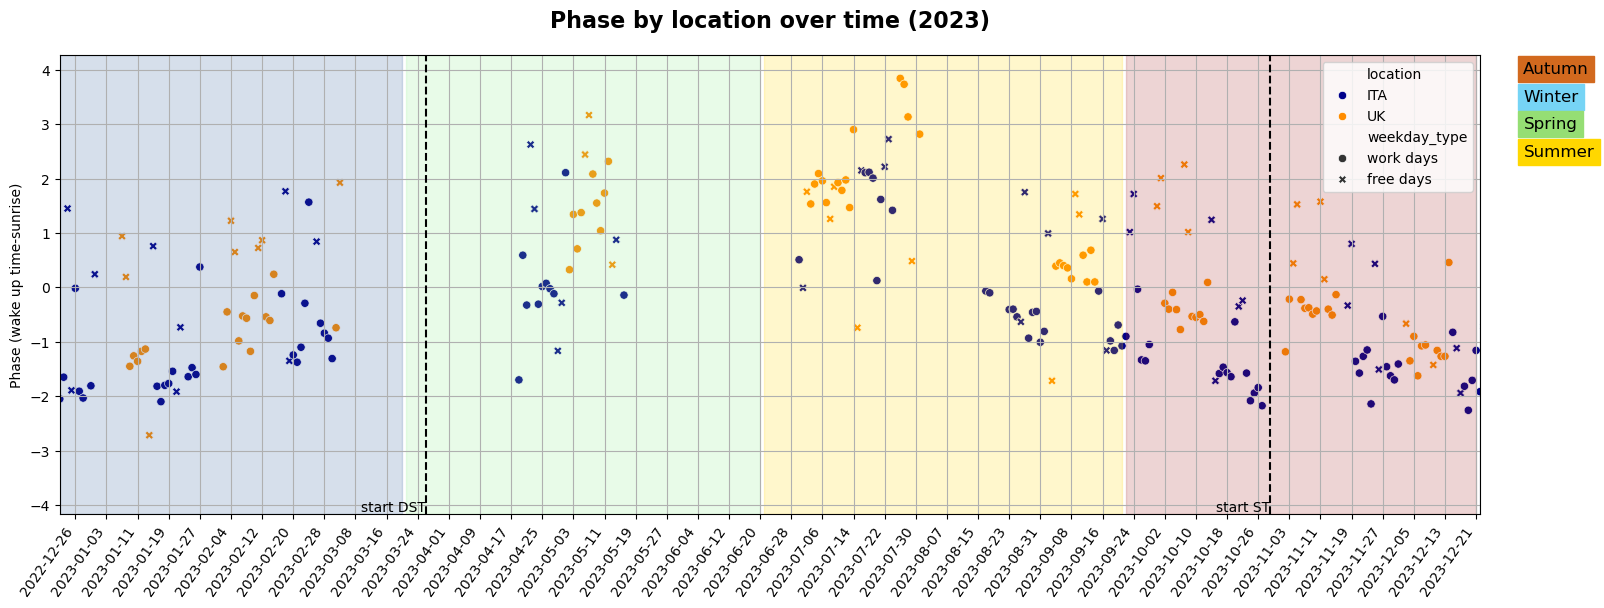

In [137]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='phase', hue='location', style='weekday_type', data=phase_bydays_after_flight, palette=['darkblue', 'darkorange'])
plt.title('Phase by location over time (2023)', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Phase (wake up time-sunrise)')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min() + pd.DateOffset(months=3), df['date'].min() + pd.DateOffset(months=15))
plt.gca().xaxis.set_major_locator(MultipleLocator(8)) #get the current axis = gca

# vertical bar to indicate the start of the DST and the start of the ST 
#plt.axvline(x=pd.to_datetime('2022-10-30'), color='black', linestyle='--')
#plt.text(pd.to_datetime('2022-10-30'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-10-29'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-10-29'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-03-26'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-03-26'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
#plt.axvline(x=pd.to_datetime('2024-03-31'), color='black', linestyle='--')
#plt.text(pd.to_datetime('2024-03-31'), plt.ylim()[0], 'start DST', ha='right', va='bottom')

# define seasons
seasons = [
    ('2022-09-22', '2022-12-21', 'brown'),  # Autumn
    ('2022-12-22', '2023-03-20', '#335f9e'),  # Winter
    ('2023-03-21', '2023-06-20', 'lightgreen'), # Spring
    ('2023-06-21', '2023-09-21', 'gold'),     # Summer
    ('2023-09-22', '2023-12-21', 'brown'),  # Autumn
    ('2023-12-22', '2024-03-20', '#335f9e'),  # Winter
    ('2024-03-21', '2024-06-20', 'lightgreen'), # Spring
    ('2024-06-21', '2024-09-21', 'gold'),     # Summer
    ('2024-09-22', '2024-12-21', 'brown'),  # Autumn
]

# apply the background color for each season
for start, end, color in seasons:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.2)

plt.annotate('Summer', xy=(1.0555, 0.79), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='gold')
plt.annotate('Autumn', xy=(1.0535, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='chocolate')
plt.annotate('Winter', xy=(1.05, 0.91), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#76d4f5')
plt.annotate('Spring', xy=(1.0499, 0.85), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#95de74')

plt.show()

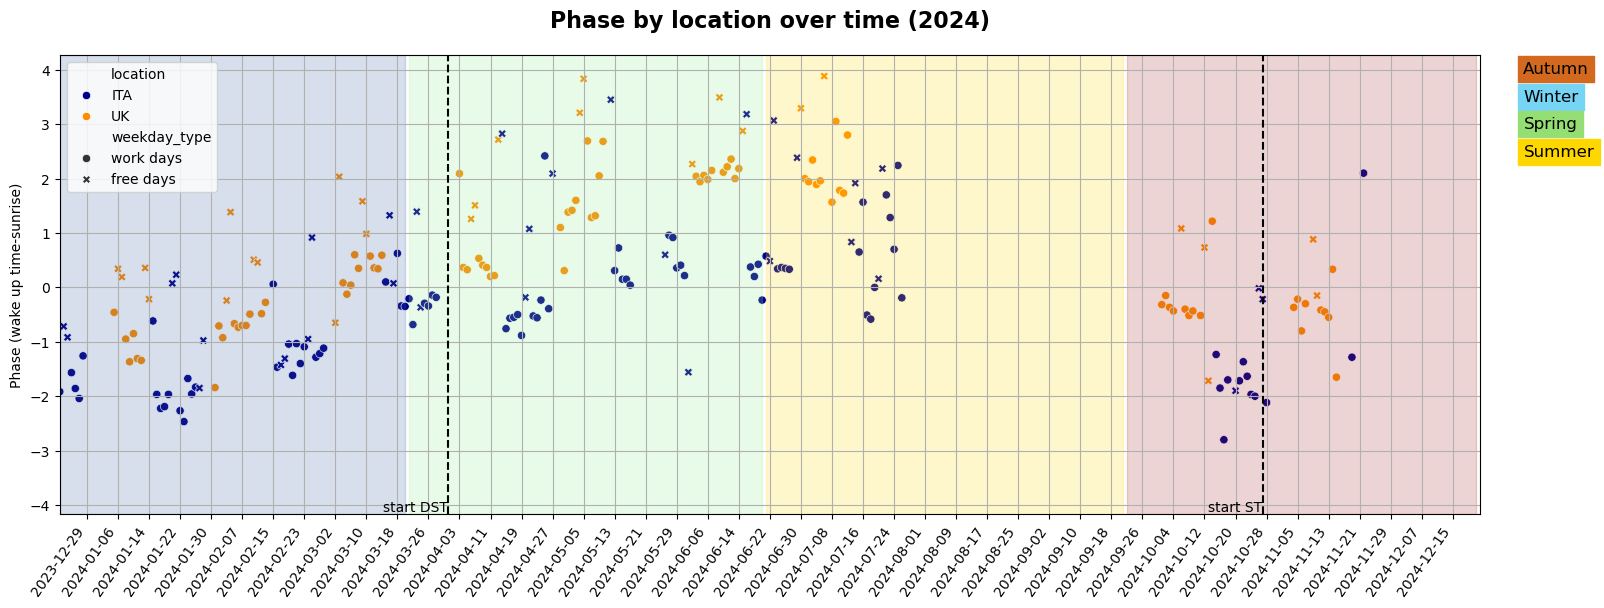

In [138]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='phase', hue='location', style='weekday_type', data=phase_bydays_after_flight, palette=['darkblue', 'darkorange'])
plt.title('Phase by location over time (2024)', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Phase (wake up time-sunrise)')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min() + pd.DateOffset(months=15), df['date'].min() + pd.DateOffset(months=27))
plt.gca().xaxis.set_major_locator(MultipleLocator(8)) #get the current axis = gca

# vertical bar to indicate the start of the DST and the start of the ST 
#plt.axvline(x=pd.to_datetime('2022-10-30'), color='black', linestyle='--')
#plt.text(pd.to_datetime('2022-10-30'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
#plt.axvline(x=pd.to_datetime('2023-10-29'), color='black', linestyle='--')
#plt.text(pd.to_datetime('2023-10-29'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
#plt.axvline(x=pd.to_datetime('2023-03-26'), color='black', linestyle='--')
#plt.text(pd.to_datetime('2023-03-26'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-03-31'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-03-31'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-10-27'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-10-27'), plt.ylim()[0], 'start ST', ha='right', va='bottom')

# define seasons
seasons = [
    ('2022-09-22', '2022-12-21', 'brown'),  # Autumn
    ('2022-12-22', '2023-03-20', '#335f9e'),  # Winter
    ('2023-03-21', '2023-06-20', 'lightgreen'), # Spring
    ('2023-06-21', '2023-09-21', 'gold'),     # Summer
    ('2023-09-22', '2023-12-21', 'brown'),  # Autumn
    ('2023-12-22', '2024-03-20', '#335f9e'),  # Winter
    ('2024-03-21', '2024-06-20', 'lightgreen'), # Spring
    ('2024-06-21', '2024-09-21', 'gold'),     # Summer
    ('2024-09-22', '2024-12-21', 'brown'),  # Autumn
]

# apply the background color for each season
for start, end, color in seasons:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.2)

plt.annotate('Summer', xy=(1.0555, 0.79), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='gold')
plt.annotate('Autumn', xy=(1.0535, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='chocolate')
plt.annotate('Winter', xy=(1.05, 0.91), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#76d4f5')
plt.annotate('Spring', xy=(1.0499, 0.85), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#95de74')

plt.show()

##### _The re_formula parameter specifies the structure of the random effects in the mixed-effects model_
##### _re_formula-> specifies that the random effects are independent_

Common Usage

re_formula="~1":
This specifies that the random effects are independent and only include a random intercept for each group.
In other words, each group (defined by the groups parameter) has its own intercept, but the slopes are assumed to be the same across groups.

re_formula="~ variable":
This specifies that the random effects include both a random intercept and a random slope for the specified variable.
Each group has its own intercept and its own slope for the specified variable.

re_formula="~ variable1 + variable2":
This specifies that the random effects include a random intercept and random slopes for variable1 and variable2.
Each group has its own intercept and its own slopes for variable1 and variable2.

_Sleep duration by location, time, DST and season_

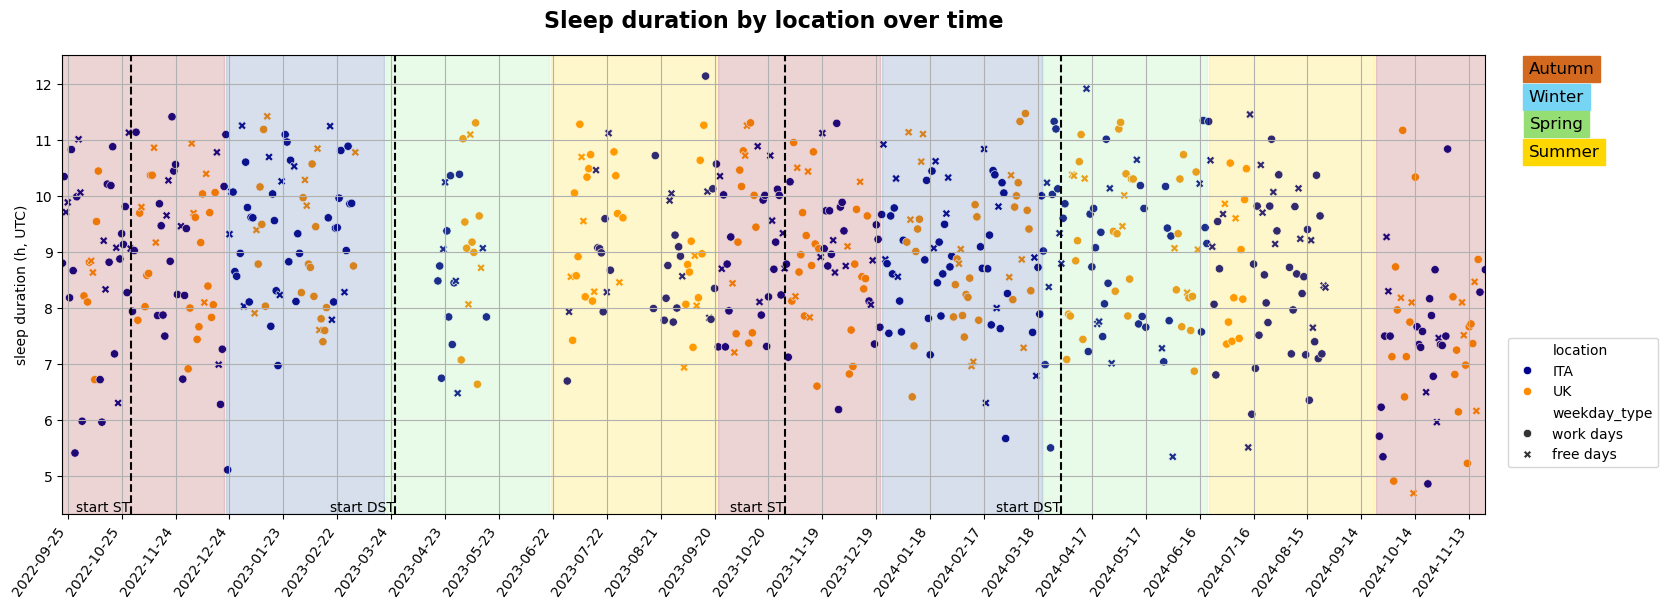

In [139]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='sleep_duration_UTC', hue='location', style='weekday_type', data=df, palette=['darkblue', 'darkorange'])
plt.title('Sleep duration by location over time', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('sleep duration (h, UTC)')
plt.xlabel('')
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min(), df['date'].max())
plt.gca().xaxis.set_major_locator(MultipleLocator(30)) #get the current axis = gca

# vertical bar to indicate the start of the DST and the start of the ST 
plt.axvline(x=pd.to_datetime('2022-10-30'), color='black', linestyle='--')
plt.text(pd.to_datetime('2022-10-30'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-10-29'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-10-29'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-03-26'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-03-26'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-03-31'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-03-31'), plt.ylim()[0], 'start DST', ha='right', va='bottom')

# define seasons
seasons = [
    ('2022-09-22', '2022-12-21', 'brown'),  # Autumn
    ('2022-12-22', '2023-03-20', '#335f9e'),  # Winter
    ('2023-03-21', '2023-06-20', 'lightgreen'), # Spring
    ('2023-06-21', '2023-09-21', 'gold'),     # Summer
    ('2023-09-22', '2023-12-21', 'brown'),  # Autumn
    ('2023-12-22', '2024-03-20', '#335f9e'),  # Winter
    ('2024-03-21', '2024-06-20', 'lightgreen'), # Spring
    ('2024-06-21', '2024-09-21', 'gold'),     # Summer
    ('2024-09-22', '2024-12-21', 'brown'),  # Autumn
]

# apply the background color for each season
for start, end, color in seasons:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.2)

plt.annotate('Summer', xy=(1.0555, 0.79), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='gold')
plt.annotate('Autumn', xy=(1.0535, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='chocolate')
plt.annotate('Winter', xy=(1.05, 0.91), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#76d4f5')
plt.annotate('Spring', xy=(1.0499, 0.85), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#95de74')

# move the legend outside the plot
plt.legend(bbox_to_anchor=(1.011, 0.4), loc='upper left')

plt.show()